<a href="https://colab.research.google.com/github/elisagigliotti/mal-dw-project/blob/main/MAL_DW_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MyAnimeList — Data Warehouse Project
**Course:** Data Warehousing & Business Intelligence

**Data sources:**
| File | Description |
|------|-------------|
| `anime.csv` | 28,858 anime — master table, 58 columns |
| `UserList.csv` | 302,675 users with profile data |
| `UserAnimeList.csv` | Transactional fact table (millions of rows) |

---
## Table of contents
| Section | Phase | Content |
|---------|-------|---------|
| §0 | Setup | Installations, imports, DB connections |
| §1 | Phase 1 — Step 2 | Re-engineering & reconciled schema |
| §2 | Phase 2 — Step 1 | Load raw data into reconciled DB |
| §3 | Phase 2 — Step 2a | Data Quality Assessment |
| §4 | Phase 2 — Step 2b | Data Cleaning |
| §5 | Phase 2 — Step 2c | LLM Support Layer |
| §6 | Phase 1 — Steps 4–5 / Phase 2 — Step 4 | ETL → Star Schema (Data Warehouse) |
| §7 | Phase 3 | Export for Tableau |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 00 — Setup & Configuration
**MyAnimeList Data Warehouse Project**

This notebook handles all installations, imports, file paths and database connections.
Run this first before any other notebook.

---
### Data sources
| File | Description |
|------|-------------|
| `anime.csv` | 28,858 anime — master table, 58 columns |
| `UserList.csv` | 302,675 users with profile data |
| `UserAnimeList.csv` | Transactional fact table (millions of rows) |


## 0.1 — Install dependencies

In [2]:
 # Install required libraries
# Run only once per Colab session
!pip install pandas sqlalchemy matplotlib seaborn missingno tabulate scikit-learn scipy -q

import warnings
warnings.filterwarnings('ignore')
print("Libraries installed successfully.")


Libraries installed successfully.


## 0.2 — Global imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import re
import os
import ast
from datetime import datetime
from tabulate import tabulate
from sqlalchemy import create_engine, text, inspect

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print("Imports complete.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")


Imports complete.
  pandas  2.2.2
  numpy   2.0.2


## 0.3 — File paths

**Option A (default):** upload your CSV files to `/content/data/`  
**Option B:** mount Google Drive and point `DATA_DIR` to your folder


In [4]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/DW_Project/data'
BASE_PATH = '/content/drive/MyDrive/DW_Project/'

# ── CSV file paths ────────────────────────────────────────────────────────────
ANIME_CSV   = os.path.join(DATA_DIR, 'anime.csv')
USERS_CSV   = os.path.join(DATA_DIR, 'UserList.csv')
RATINGS_CSV = os.path.join(DATA_DIR, 'UserAnimeList.csv')

# ── Chunk size for large files (reduce if Colab runs out of RAM) ──────────────
RATINGS_CHUNKSIZE = 500_000

# ── Check files exist ─────────────────────────────────────────────────────────
for label, path in [('anime.csv', ANIME_CSV),
                    ('UserList.csv', USERS_CSV),
                    ('UserAnimeList.csv', RATINGS_CSV)]:
    status = '✅' if os.path.exists(path) else '❌  NOT FOUND — upload before continuing'
    print(f"  {status}  {label}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅  anime.csv
  ✅  UserList.csv
  ✅  UserAnimeList.csv


## 0.4 — Database connections

In [5]:
# ── Paths for the two SQLite databases ───────────────────────────────────────
# Reconciled DB: faithful copy of sources, normalized to 3NF
# Data Warehouse: star schema, ready for OLAP analysis
DB_REC_PATH = '/content/mal_reconciled.db'
DB_DW_PATH  = '/content/mal_dw.db'

# SQLite engines (no server required — perfect for Colab)
engine_rec = create_engine(f'sqlite:///{DB_REC_PATH}', echo=False)
engine_dw  = create_engine(f'sqlite:///{DB_DW_PATH}',  echo=False)

print("Database engines created.")
print(f"  Reconciled DB : {DB_REC_PATH}")
print(f"  Data Warehouse: {DB_DW_PATH}")


Database engines created.
  Reconciled DB : /content/mal_reconciled.db
  Data Warehouse: /content/mal_dw.db


## 0.5 — Shared utilities

In [6]:
def row_count(engine, table):
    """Return the number of rows in a table."""
    with engine.connect() as conn:
        return conn.execute(text(f'SELECT COUNT(*) FROM "{table}"')).scalar()

def show_table(engine, table, n=3):
    """Display the first n rows of a table."""
    with engine.connect() as conn:
        df = pd.read_sql(f'SELECT * FROM "{table}" LIMIT {n}', conn)
    display(df)

def db_summary(engine, label='Database'):
    """Print a summary of all tables and their row counts."""
    insp = inspect(engine)
    tables = insp.get_table_names()
    print(f"\n{'─'*40}  {label}")
    for t in tables:
        n = row_count(engine, t)
        print(f"  {t:<30} {n:>10,} rows")

print("Utilities ready.")


Utilities ready.


## 1.0 — Load raw CSVs

In [7]:
# Load anime CSV (most recent, 58 columns)
anime_raw = pd.read_csv(ANIME_CSV, encoding='utf-8', low_memory=False)
print(f"anime_raw    : {anime_raw.shape[0]:>7,} rows × {anime_raw.shape[1]} columns")

# Load users CSV
users_raw = pd.read_csv(USERS_CSV, encoding='latin1', low_memory=False)
print(f"users_raw    : {users_raw.shape[0]:>7,} rows × {users_raw.shape[1]} columns")

# Load ratings — peek only
ratings_raw = pd.read_csv(RATINGS_CSV, encoding='latin1', nrows=5)
print(f"ratings peek : {ratings_raw.shape[1]} columns")
print(f"  columns    : {ratings_raw.columns.tolist()}")


anime_raw    :  28,858 rows × 58 columns
users_raw    : 302,675 rows × 17 columns
ratings peek : 11 columns
  columns    : ['username', 'anime_id', 'my_watched_episodes', 'my_start_date', 'my_finish_date', 'my_score', 'my_status', 'my_rewatching', 'my_rewatching_ep', 'my_last_updated', 'my_tags']


## 1.1 — Explore source structure

In [8]:
def explore(df, name, max_cols=40):
    """Print column types and a sample row for a DataFrame."""
    print(f"\n{'═'*60}")
    print(f"  {name}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
    print(f"{'═'*60}")
    print(df.dtypes.to_string())
    print("\n--- Sample row ---")
    display(df.head(2))

explore(anime_raw,   'ANIME ')
explore(users_raw,   'USERS ')



════════════════════════════════════════════════════════════
  ANIME (Archive 9)  (28,858 rows × 58 columns)
════════════════════════════════════════════════════════════
mal_id                         int64
url                           object
approved                        bool
title                         object
title_english                 object
title_japanese                object
title_synonyms                object
image_jpg_url                 object
image_jpg_small_url           object
image_jpg_large_url           object
image_webp_url                object
image_webp_small_url          object
image_webp_large_url          object
trailer_youtube_id            object
trailer_url                   object
trailer_embed_url             object
trailer_image_url             object
trailer_small_image_url       object
trailer_medium_image_url      object
trailer_large_image_url       object
trailer_maximum_image_url     object
type                          object
source         

,mal_id,url,approved,title,title_english,title_japanese,title_synonyms,image_jpg_url,image_jpg_small_url,image_jpg_large_url,image_webp_url,image_webp_small_url,image_webp_large_url,trailer_youtube_id,trailer_url,trailer_embed_url,trailer_image_url,trailer_small_image_url,trailer_medium_image_url,trailer_large_image_url,trailer_maximum_image_url,type,source,episodes,status,airing,duration,rating,score,scored_by,rank,popularity,members,favorites,synopsis,background,aired_from,aired_to,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,aired_string,season,year,broadcast_day,broadcast_time,broadcast_timezone,broadcast_string,producers,licensors,studios,genres,explicit_genres,themes,demographics
0,1,https://myanimelist.net/anime/1/Cowboy_Bebop,True,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,NaN,https://cdn.myanimelist.net/images/anime/4/19644.jpg,https://cdn.myanimelist.net/images/anime/4/19644t.jpg,https://cdn.myanimelist.net/images/anime/4/19644l.jpg,https://cdn.myanimelist.net/images/anime/4/19644.webp,https://cdn.myanimelist.net/images/anime/4/19644t.webp,https://cdn.myanimelist.net/images/anime/4/19644l.webp,gY5nDXOtv_o,https://www.youtube.com/watch?v=gY5nDXOtv_o,https://www.youtube.com/embed/gY5nDXOtv_o?enablejsapi=1&wmode=opaque&autoplay=1,https://img.youtube.com/vi/gY5nDXOtv_o/default.jpg,https://img.youtube.com/vi/gY5nDXOtv_o/sddefault.jpg,https://img.youtube.com/vi/gY5nDXOtv_o/mqdefault.jpg,https://img.youtube.com/vi/gY5nDXOtv_o/hqdefault.jpg,https://img.youtube.com/vi/gY5nDXOtv_o/maxresdefault.jpg,TV,Original,26.00,Finished Airing,False,24 min per ep,R - 17+ (violence & profanity),8.75,1023989.00,47.00,42,1983687,86885,"Crime is timeless. By the year 2071, humanity has expanded across the galaxy...","When Cowboy Bebop first aired in spring of 1998 on TV Tokyo, only episodes 2...",1998-04-03T00:00:00+00:00,1999-04-24T00:00:00+00:00,3.00,4.00,1998.00,24.00,4.00,1999.00,"Apr 3, 1998 to Apr 24, 1999",spring,1998.00,Saturdays,01:00,Asia/Tokyo,Saturdays at 01:00 (JST),"Bandai Visual, Victor Entertainment, Audio Planning U",Funimation,Sunrise,"Action, Award Winning, Sci-Fi",NaN,"Adult Cast, Space",NaN
1,5,https://myanimelist.net/anime/5/Cowboy_Bebop__Tengoku_no_Tobira,True,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Cowboy Bebop: Knockin' on Heaven's Door,https://cdn.myanimelist.net/images/anime/1439/93480.jpg,https://cdn.myanimelist.net/images/anime/1439/93480t.jpg,https://cdn.myanimelist.net/images/anime/1439/93480l.jpg,https://cdn.myanimelist.net/images/anime/1439/93480.webp,https://cdn.myanimelist.net/images/anime/1439/93480t.webp,https://cdn.myanimelist.net/images/anime/1439/93480l.webp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Movie,Original,1.00,Finished Airing,False,1 hr 55 min,R - 17+ (violence & profanity),8.38,226048.00,217.00,643,399427,1718,"Another day, another bounty—such is the life of the often unlucky crew of th...",NaN,2001-09-01T00:00:00+00:00,NaN,1.00,9.00,2001.00,NaN,NaN,NaN,"Sep 1, 2001",NaN,NaN,NaN,NaN,NaN,NaN,"Sunrise, Bandai Visual","Sony Pictures Entertainment, Funimation",Bones,"Action, Sci-Fi",NaN,"Adult Cast, Space",NaN



════════════════════════════════════════════════════════════
  USERS (Archive 6)  (302,675 rows × 17 columns)
════════════════════════════════════════════════════════════
username                     object
user_id                       int64
user_watching                 int64
user_completed                int64
user_onhold                   int64
user_dropped                  int64
user_plantowatch              int64
user_days_spent_watching    float64
gender                       object
location                     object
birth_date                   object
access_rank                 float64
join_date                    object
last_online                  object
stats_mean_score            float64
stats_rewatched             float64
stats_episodes              float64

--- Sample row ---


,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes
0,karthiga,2255153,3,49,1,0,0,55.31,Female,"Chennai, India",1990-04-29,NaN,2013-03-03,2014-02-04 01:32:00,7.43,0.00,3391.00
1,RedvelvetDaisuki,1897606,61,396,39,0,206,118.07,Female,Manila,1995-01-01,NaN,2012-12-13,1900-05-13 02:47:00,6.78,80.00,7094.00


## 1.2 — Extract multi-value entities from `anime.csv`

### The problem
Columns like `genres` contain comma-separated strings:
```
'Action, Award Winning, Sci-Fi, Space'
```
This is a **multi-value attribute** — a violation of 1NF.
In a normalized schema, each value becomes a row in a bridge table.

### Solution: explode → lookup + bridge
For each multi-value column we produce:
- A **lookup table** with a surrogate key (e.g. `genre_id`, `genre_name`)
- A **bridge table** with the N:N pairs (e.g. `anime_genre(mal_id, genre_id)`)


In [9]:
def explode_multival(df, id_col, raw_col, id_name, name_col):
    """
    Explode a multi-value string column into a lookup table and a bridge table.

    Parameters
    ----------
    df       : source DataFrame
    id_col   : primary key of the main entity (e.g. 'mal_id')
    raw_col  : column containing comma-separated values (e.g. 'genres')
    id_name  : surrogate key name for the lookup (e.g. 'genre_id')
    name_col : value column name in the lookup (e.g. 'genre_name')

    Returns
    -------
    lookup : DataFrame(id_name, name_col)   — unique values with surrogate key
    bridge : DataFrame(id_col, id_name)     — N:N association pairs
    """
    rows = []
    for _, row in df[[id_col, raw_col]].dropna(subset=[raw_col]).iterrows():
        for val in str(row[raw_col]).split(','):
            val = val.strip()
            if val:
                rows.append({id_col: row[id_col], name_col: val})

    bridge_raw = pd.DataFrame(rows).drop_duplicates()

    # Build lookup with surrogate key
    unique_vals = sorted(bridge_raw[name_col].unique())
    lookup = pd.DataFrame({
        id_name:  range(1, len(unique_vals) + 1),
        name_col: unique_vals
    })

    # Map values to surrogate keys in the bridge
    name_to_id = dict(zip(lookup[name_col], lookup[id_name]))
    bridge_raw[id_name] = bridge_raw[name_col].map(name_to_id)
    bridge = bridge_raw[[id_col, id_name]].drop_duplicates()

    return lookup, bridge


# ── Extract all four multi-value entities ─────────────────────────────────────
genre_lookup,  anime_genre_bridge  = explode_multival(anime_raw, 'mal_id', 'genres',       'genre_id',  'genre_name')
studio_lookup, anime_studio_bridge = explode_multival(anime_raw, 'mal_id', 'studios',      'studio_id', 'studio_name')
theme_lookup,  anime_theme_bridge  = explode_multival(anime_raw, 'mal_id', 'themes',       'theme_id',  'theme_name')
demo_lookup,   anime_demo_bridge   = explode_multival(anime_raw, 'mal_id', 'demographics', 'demo_id',   'demo_name')

print("Entities extracted:")
print(f"  genre_lookup         : {len(genre_lookup):>5} unique genres")
print(f"  anime_genre (bridge) : {len(anime_genre_bridge):>5} anime↔genre pairs")
print(f"  studio_lookup        : {len(studio_lookup):>5} unique studios")
print(f"  anime_studio (bridge): {len(anime_studio_bridge):>5} anime↔studio pairs")
print(f"  theme_lookup         : {len(theme_lookup):>5} unique themes")
print(f"  anime_theme (bridge) : {len(anime_theme_bridge):>5} anime↔theme pairs")
print(f"  demo_lookup          : {len(demo_lookup):>5} unique demographics")
print(f"  anime_demo (bridge)  : {len(anime_demo_bridge):>5} anime↔demographic pairs")


Entities extracted:
  genre_lookup         :    21 unique genres
  anime_genre (bridge) : 42588 anime↔genre pairs
  studio_lookup        :  1270 unique studios
  anime_studio (bridge): 18519 anime↔studio pairs
  theme_lookup         :    52 unique themes
  anime_theme (bridge) : 24000 anime↔theme pairs
  demo_lookup          :     5 unique demographics
  anime_demo (bridge)  : 10763 anime↔demographic pairs


## 1.3 — Define reconciled schema (DDL)

The reconciled database implements the **E/R schema** derived in the re-engineering step.

### Schema overview
```
Anime ─── anime_genre    ──► Genre
      ─── anime_studio   ──► Studio
      ─── anime_theme    ──► Theme
      ─── anime_demographic ──► Demographic

User  ─── Evaluation ────────► Anime
```

`Evaluation` is the **operational fact table**: each row is one user's rating
of one anime, with score, status, and episodes watched.


In [10]:
DDL_RECONCILED = """
-- ── Lookup tables ──────────────────────────────────────────────────────────
CREATE TABLE IF NOT EXISTS genre (
    genre_id    INTEGER PRIMARY KEY,
    genre_name  TEXT    NOT NULL UNIQUE
);

CREATE TABLE IF NOT EXISTS studio (
    studio_id   INTEGER PRIMARY KEY,
    studio_name TEXT    NOT NULL UNIQUE
);

CREATE TABLE IF NOT EXISTS theme (
    theme_id    INTEGER PRIMARY KEY,
    theme_name  TEXT    NOT NULL UNIQUE
);

CREATE TABLE IF NOT EXISTS demographic (
    demo_id     INTEGER PRIMARY KEY,
    demo_name   TEXT    NOT NULL UNIQUE
);

-- ── Main entity: Anime ──────────────────────────────────────────────────────
-- duration_text : raw string from source ('24 min. per ep.')
-- duration_min  : parsed integer, populated during cleaning (04_cleaning.ipynb)
-- country       : derived from location during cleaning
CREATE TABLE IF NOT EXISTS anime (
    mal_id          INTEGER PRIMARY KEY,
    title           TEXT,
    title_english   TEXT,
    title_japanese  TEXT,
    type            TEXT,
    source          TEXT,
    episodes        INTEGER,
    status          TEXT,
    duration_text   TEXT,
    duration_min    REAL,
    rating          TEXT,
    score           REAL,
    scored_by       INTEGER,
    rank            INTEGER,
    popularity      INTEGER,
    members         INTEGER,
    favorites       INTEGER,
    synopsis        TEXT,
    aired_from      TEXT,
    aired_to        TEXT,
    season          TEXT,
    year            INTEGER,
    broadcast_day   TEXT,
    broadcast_time  TEXT
);

-- ── Bridge tables (N:N) ─────────────────────────────────────────────────────
CREATE TABLE IF NOT EXISTS anime_genre (
    mal_id    INTEGER REFERENCES anime(mal_id),
    genre_id  INTEGER REFERENCES genre(genre_id),
    PRIMARY KEY (mal_id, genre_id)
);

CREATE TABLE IF NOT EXISTS anime_studio (
    mal_id    INTEGER REFERENCES anime(mal_id),
    studio_id INTEGER REFERENCES studio(studio_id),
    PRIMARY KEY (mal_id, studio_id)
);

CREATE TABLE IF NOT EXISTS anime_theme (
    mal_id    INTEGER REFERENCES anime(mal_id),
    theme_id  INTEGER REFERENCES theme(theme_id),
    PRIMARY KEY (mal_id, theme_id)
);

CREATE TABLE IF NOT EXISTS anime_demographic (
    mal_id   INTEGER REFERENCES anime(mal_id),
    demo_id  INTEGER REFERENCES demographic(demo_id),
    PRIMARY KEY (mal_id, demo_id)
);

-- ── User ───────────────────────────────────────────────────────────────────
-- country: cleaned/derived from the raw 'location' field (populated in §4)
CREATE TABLE IF NOT EXISTS user (
    user_id             INTEGER PRIMARY KEY,
    username            TEXT,
    gender              TEXT,
    location            TEXT,
    country             TEXT,
    birth_date          TEXT,
    join_date           TEXT,
    last_online         TEXT,
    days_spent_watching REAL,
    stats_mean_score    REAL,
    stats_rewatched     INTEGER,
    stats_episodes      INTEGER,
    user_watching       INTEGER,
    user_completed      INTEGER,
    user_onhold         INTEGER,
    user_dropped        INTEGER,
    user_plantowatch    INTEGER
);

-- ── Evaluation (operational fact table) ───────────────────────────────────
-- PK is the composite (user_id, mal_id): one rating per user per anime
-- score=0 is treated as 'not rated' and will be set to NULL during cleaning
CREATE TABLE IF NOT EXISTS evaluation (
    user_id          INTEGER REFERENCES user(user_id),
    mal_id           INTEGER REFERENCES anime(mal_id),
    score            INTEGER,
    watching_status  TEXT,
    watched_episodes INTEGER,
    PRIMARY KEY (user_id, mal_id)
);
"""

# Create the schema on SQLite
with engine_rec.connect() as conn:
    for stmt in DDL_RECONCILED.strip().split(';'):
        stmt = stmt.strip()
        if stmt:
            conn.execute(text(stmt))
    conn.commit()

# Verify
insp = inspect(engine_rec)
print("Reconciled DB tables created:")
for t in insp.get_table_names():
    print(f"  • {t}")


Reconciled DB tables created:
  • anime
  • anime_demographic
  • anime_genre
  • anime_studio
  • anime_theme
  • demographic
  • evaluation
  • genre
  • studio
  • theme
  • user


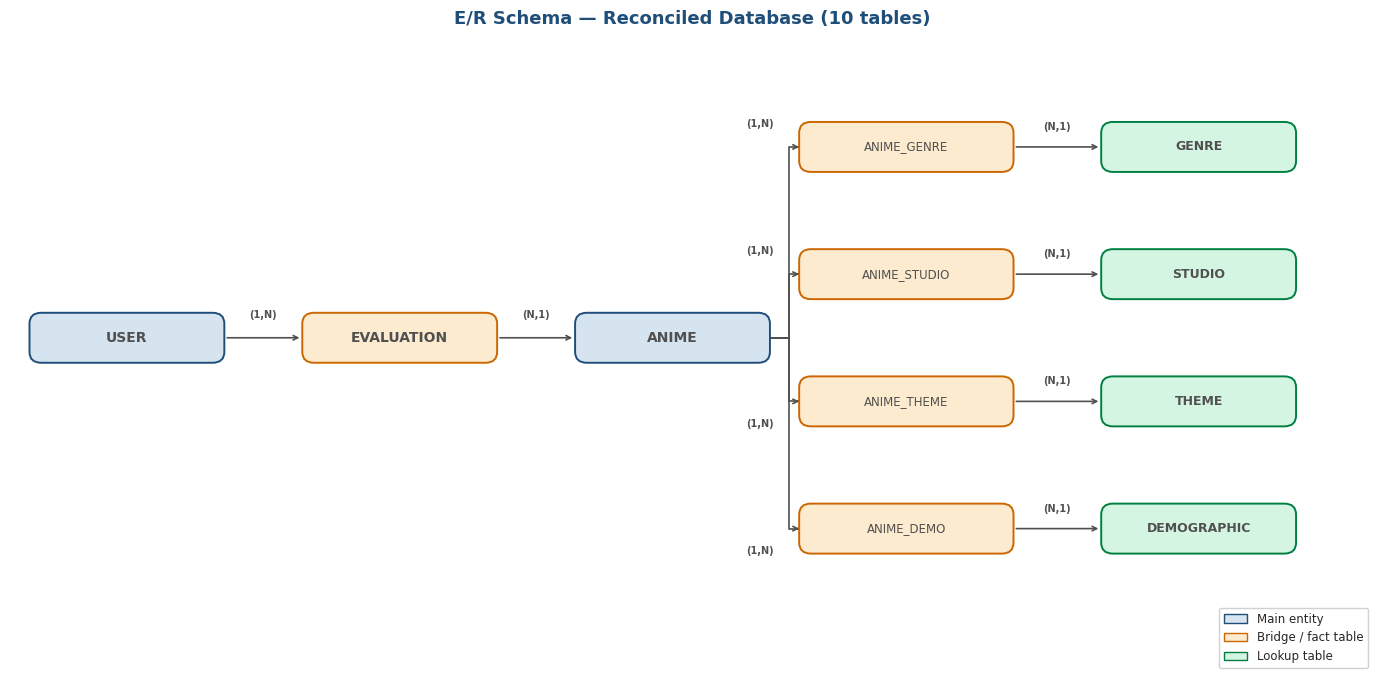

✓ er_schema.png saved to /content/drive/MyDrive/DW_Project/


In [11]:
# ── E/R Schema diagram ────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

C_BLUE_DARK    = "#1F4E79"
C_BLUE_LIGHT   = "#D6E4F0"
C_ORANGE_DARK  = "#CC6600"
C_ORANGE_LIGHT = "#FDEBD0"
C_GREEN_DARK   = "#008040"
C_GREEN_LIGHT  = "#D5F5E3"
C_GRAY_DARK    = "#505050"

def _box(ax, cx, cy, w, h, label, fc, ec, fontsize=9, bold=False, radius=0.12):
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        fc=fc, ec=ec, lw=1.4, zorder=3))
    ax.text(cx, cy, label, ha='center', va='center',
            fontsize=fontsize,
            fontweight='bold' if bold else 'normal',
            color=C_GRAY_DARK, zorder=4)

def _arr(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->',
                                color=C_GRAY_DARK, lw=1.2,
                                mutation_scale=8), zorder=2)

def _card(ax, x, y, text):
    ax.text(x, y, text, ha='center', va='center', fontsize=7,
            fontweight='bold', color=C_GRAY_DARK, zorder=5,
            bbox=dict(fc='white', ec='none', pad=1.5))

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis('off')
fig.patch.set_facecolor('white')

BW, BH = 2.0, 0.55

# Main entities
_box(ax, 1.2, 3.7, BW, BH, "USER",       C_BLUE_LIGHT,   C_BLUE_DARK,   10, True)
_box(ax, 4.0, 3.7, BW, BH, "EVALUATION", C_ORANGE_LIGHT, C_ORANGE_DARK, 10, True)
_box(ax, 6.8, 3.7, BW, BH, "ANIME",      C_BLUE_LIGHT,   C_BLUE_DARK,   10, True)

# Bridge + lookup tables
for y, lb, ll in zip(
        [5.8, 4.4, 3.0, 1.6],
        ["ANIME_GENRE", "ANIME_STUDIO", "ANIME_THEME", "ANIME_DEMO"],
        ["GENRE",       "STUDIO",       "THEME",       "DEMOGRAPHIC"]):
    _box(ax, 9.2,  y, 2.2, BH, lb, C_ORANGE_LIGHT, C_ORANGE_DARK, 8.5)
    _box(ax, 12.2, y, 2.0, BH, ll, C_GREEN_LIGHT,  C_GREEN_DARK,  9, True)

# USER → EVALUATION → ANIME
_arr(ax, 1.2 + BW/2, 3.7, 4.0 - BW/2, 3.7)
_card(ax, 2.6, 3.95, "(1,N)")
_arr(ax, 4.0 + BW/2, 3.7, 6.8 - BW/2, 3.7)
_card(ax, 5.4, 3.95, "(N,1)")

# ANIME → bridges (elbow routing)
for y, co in zip([5.8, 4.4, 3.0, 1.6], [0.25, 0.25, -0.25, -0.25]):
    mx = 6.8 + BW/2 + 0.2
    ax.plot([6.8 + BW/2, mx, mx, 9.2 - 1.1],
            [3.7, 3.7, y, y],
            color=C_GRAY_DARK, lw=1.2, zorder=2)
    ax.annotate('', xy=(9.2 - 1.1, y), xytext=(9.2 - 1.12, y),
                arrowprops=dict(arrowstyle='->', color=C_GRAY_DARK,
                                lw=1.2, mutation_scale=8), zorder=2)
    _card(ax, 9.2 - 1.1 - 0.4, y + co, "(1,N)")

# Bridges → lookups
for y in [5.8, 4.4, 3.0, 1.6]:
    _arr(ax, 9.2 + 1.1, y, 12.2 - 1.0, y)
    _card(ax, (9.2 + 1.1 + 12.2 - 1.0) / 2, y + 0.22, "(N,1)")

ax.legend(handles=[
    mpatches.Patch(fc=C_BLUE_LIGHT,   ec=C_BLUE_DARK,   label='Main entity'),
    mpatches.Patch(fc=C_ORANGE_LIGHT, ec=C_ORANGE_DARK, label='Bridge / fact table'),
    mpatches.Patch(fc=C_GREEN_LIGHT,  ec=C_GREEN_DARK,  label='Lookup table'),
], loc='lower right', fontsize=8.5, framealpha=0.9)

ax.set_title("E/R Schema — Reconciled Database (10 tables)",
             fontsize=13, fontweight='bold', color=C_BLUE_DARK, pad=10)

plt.tight_layout()
plt.savefig(BASE_PATH + 'er_schema.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ er_schema.png saved to", BASE_PATH)

## 1.4 — Save extracted entities for loading step

In [12]:
# Persist the extracted lookup and bridge DataFrames so that
EXTRACTED_DIR = '/content/extracted'
os.makedirs(EXTRACTED_DIR, exist_ok=True)

genre_lookup.to_csv(f'{EXTRACTED_DIR}/genre_lookup.csv', index=False)
studio_lookup.to_csv(f'{EXTRACTED_DIR}/studio_lookup.csv', index=False)
theme_lookup.to_csv(f'{EXTRACTED_DIR}/theme_lookup.csv', index=False)
demo_lookup.to_csv(f'{EXTRACTED_DIR}/demo_lookup.csv', index=False)

anime_genre_bridge.to_csv(f'{EXTRACTED_DIR}/anime_genre.csv', index=False)
anime_studio_bridge.to_csv(f'{EXTRACTED_DIR}/anime_studio.csv', index=False)
anime_theme_bridge.to_csv(f'{EXTRACTED_DIR}/anime_theme.csv', index=False)
anime_demo_bridge.to_csv(f'{EXTRACTED_DIR}/anime_demo.csv', index=False)

print(f"Extracted files saved to: {EXTRACTED_DIR}")
for f in os.listdir(EXTRACTED_DIR):
    path = os.path.join(EXTRACTED_DIR, f)
    df   = pd.read_csv(path)
    print(f"  {f:<30} {len(df):>8,} rows")


Extracted files saved to: /content/extracted
  theme_lookup.csv                     52 rows
  anime_genre.csv                  42,588 rows
  anime_theme.csv                  24,000 rows
  anime_demo.csv                   10,763 rows
  studio_lookup.csv                 1,270 rows
  demo_lookup.csv                       5 rows
  genre_lookup.csv                     21 rows
  anime_studio.csv                 18,519 rows


## 2.0 — Run setup

## 2.1 — Load lookup and bridge tables

These were extracted in `01_reengineering.ipynb`.

In [13]:
EXTRACTED_DIR = '/content/extracted'

# Load extracted entities
genre_lookup       = pd.read_csv(f'{EXTRACTED_DIR}/genre_lookup.csv')
studio_lookup      = pd.read_csv(f'{EXTRACTED_DIR}/studio_lookup.csv')
theme_lookup       = pd.read_csv(f'{EXTRACTED_DIR}/theme_lookup.csv')
demo_lookup        = pd.read_csv(f'{EXTRACTED_DIR}/demo_lookup.csv')
anime_genre_bridge = pd.read_csv(f'{EXTRACTED_DIR}/anime_genre.csv')
anime_studio_bridge= pd.read_csv(f'{EXTRACTED_DIR}/anime_studio.csv')
anime_theme_bridge = pd.read_csv(f'{EXTRACTED_DIR}/anime_theme.csv')
anime_demo_bridge  = pd.read_csv(f'{EXTRACTED_DIR}/anime_demo.csv')

# Write to reconciled DB
genre_lookup.to_sql('genre',          engine_rec, if_exists='replace', index=False)
studio_lookup.to_sql('studio',        engine_rec, if_exists='replace', index=False)
theme_lookup.to_sql('theme',          engine_rec, if_exists='replace', index=False)
demo_lookup.to_sql('demographic',     engine_rec, if_exists='replace', index=False)
anime_genre_bridge.to_sql('anime_genre',        engine_rec, if_exists='replace', index=False)
anime_studio_bridge.to_sql('anime_studio',      engine_rec, if_exists='replace', index=False)
anime_theme_bridge.to_sql('anime_theme',        engine_rec, if_exists='replace', index=False)
anime_demo_bridge.to_sql('anime_demographic',   engine_rec, if_exists='replace', index=False)

print("Lookup and bridge tables loaded:")
for t in ['genre','studio','theme','demographic',
          'anime_genre','anime_studio','anime_theme','anime_demographic']:
    print(f"  {t:<25} {row_count(engine_rec, t):>8,} rows")


Lookup and bridge tables loaded:
  genre                           21 rows
  studio                       1,270 rows
  theme                           52 rows
  demographic                      5 rows
  anime_genre                 42,588 rows
  anime_studio                18,519 rows
  anime_theme                 24,000 rows
  anime_demographic           10,763 rows


## 2.2 — Load anime table

In [14]:
# Columns to keep in the anime table
# URL, image and trailer columns are excluded — not useful for analysis
ANIME_COLS = [
    'mal_id', 'title', 'title_english', 'title_japanese',
    'type', 'source', 'episodes', 'status',
    'duration',   # raw string — will be parsed during cleaning
    'rating', 'score', 'scored_by', 'rank', 'popularity',
    'members', 'favorites', 'synopsis',
    'aired_from', 'aired_to', 'season', 'year',
    'broadcast_day', 'broadcast_time'
]

anime_raw = pd.read_csv(ANIME_CSV, encoding='utf-8', low_memory=False)
anime_load = anime_raw[ANIME_COLS].copy()

# Rename 'duration' → 'duration_text' to clarify it is still the raw string
anime_load = anime_load.rename(columns={'duration': 'duration_text'})
# Placeholder for the parsed numeric value (populated in 04_cleaning.ipynb)
anime_load['duration_min'] = None

anime_load.to_sql('anime', engine_rec, if_exists='replace', index=False)
print(f"anime table loaded: {row_count(engine_rec, 'anime'):,} rows")
show_table(engine_rec, 'anime', 2)


anime table loaded: 28,858 rows


,mal_id,title,title_english,title_japanese,type,source,episodes,status,duration_text,rating,score,scored_by,rank,popularity,members,favorites,synopsis,aired_from,aired_to,season,year,broadcast_day,broadcast_time,duration_min
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.00,Finished Airing,24 min per ep,R - 17+ (violence & profanity),8.75,1023989.00,47.00,42,1983687,86885,"Crime is timeless. By the year 2071, humanity has expanded across the galaxy...",1998-04-03T00:00:00+00:00,1999-04-24T00:00:00+00:00,spring,1998.00,Saturdays,01:00,None
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.00,Finished Airing,1 hr 55 min,R - 17+ (violence & profanity),8.38,226048.00,217.00,643,399427,1718,"Another day, another bounty—such is the life of the often unlucky crew of th...",2001-09-01T00:00:00+00:00,None,None,NaN,None,None,None


## 2.3 — Load user table

In [15]:
users_raw = pd.read_csv(USERS_CSV, encoding='latin1', low_memory=False)

# Rename columns to match the reconciled schema
users_load = users_raw.rename(columns={
    'user_days_spent_watching': 'days_spent_watching',
}).copy()

# Placeholder: country is derived from location during cleaning
users_load['country'] = None

users_load.to_sql('user', engine_rec, if_exists='replace', index=False)
print(f"user table loaded: {row_count(engine_rec, 'user'):,} rows")
show_table(engine_rec, 'user', 2)


user table loaded: 302,675 rows


,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes,country
0,karthiga,2255153,3,49,1,0,0,55.31,Female,"Chennai, India",1990-04-29,None,2013-03-03,2014-02-04 01:32:00,7.43,0.00,3391.00,None
1,RedvelvetDaisuki,1897606,61,396,39,0,206,118.07,Female,Manila,1995-01-01,None,2012-12-13,1900-05-13 02:47:00,6.78,80.00,7094.00,None


## 2.4 — Load evaluation table (large file handling)

`UserAnimeList.csv` can be several GB. We support both direct loading (if RAM allows)
and chunk-based loading for large environments.


In [16]:
# ── Column name mapping: source CSV → reconciled DB ──────────────────────────
EVAL_COLS_MAP = {
    'username':            'username',
    'anime_id':            'mal_id',
    'my_watched_episodes': 'watched_episodes',
    'my_score':            'score',
    'my_status':           'watching_status',
}

# ── Status codes in UserAnimeList.csv ─────────────────────────────────────────
# 1 = currently watching
# 2 = completed
# 3 = on hold
# 4 = dropped
# 6 = plan to watch (excluded — no real interaction yet)
USEFUL_STATUSES = [1, 2, 3, 4]

# ── Speed up SQLite bulk inserts ──────────────────────────────────────────────
with engine_rec.connect() as conn:
    conn.execute(text("PRAGMA journal_mode = OFF"))
    conn.execute(text("PRAGMA synchronous  = OFF"))
    conn.execute(text("PRAGMA cache_size   = -64000"))  # 64 MB cache
    conn.commit()
print("SQLite bulk-load mode enabled.")

# ── Load username → user_id mapping once before the chunk loop ────────────────
with engine_rec.connect() as conn:
    user_map_df = pd.read_sql('SELECT user_id, username FROM "user"', conn)
user_map = dict(zip(user_map_df['username'], user_map_df['user_id']))
print(f"User map loaded: {len(user_map):,} entries")

def load_evaluations(path, engine, cols_map, chunksize):
    """
    Load the evaluation (UserAnimeList) CSV into the reconciled DB.
    - Filters out rows with no score AND no meaningful status
      (reduces ~80M rows to ~15-25M)
    - Resolves username → user_id via the user table
    - Handles chunk-based loading for large files
    """
    total          = 0
    skipped_filter = 0
    skipped_nouser = 0
    mode           = 'replace'

    for i, chunk in enumerate(pd.read_csv(path,
                                           encoding='latin1',
                                           chunksize=chunksize,
                                           low_memory=False)):
        # ── Step 1: keep only columns we need ────────────────────────────────
        available = {k: v for k, v in cols_map.items() if k in chunk.columns}
        chunk = chunk[list(available.keys())].rename(columns=available)

        # ── Step 2: filter — keep rows with a real score OR useful status ─────
        before_filter = len(chunk)
        chunk = chunk[
            (chunk['score'] > 0) |
            (chunk['watching_status'].isin(USEFUL_STATUSES))
        ]
        skipped_filter += before_filter - len(chunk)

        # ── Step 3: resolve username → user_id ───────────────────────────────
        chunk['user_id'] = chunk['username'].map(user_map)
        before_match = len(chunk)
        chunk = chunk.dropna(subset=['user_id'])
        skipped_nouser += before_match - len(chunk)
        chunk['user_id'] = chunk['user_id'].astype(int)

        # ── Step 4: set score=0 → NULL (cleaning C4 applied here) ────────────
        chunk['score'] = chunk['score'].replace(0, None)

        # ── Step 5: keep only reconciled schema columns ───────────────────────
        chunk = chunk[['user_id', 'mal_id', 'score',
                        'watching_status', 'watched_episodes']]

        # ── Step 6: write to DB ───────────────────────────────────────────────
        chunk.to_sql('evaluation', engine, if_exists=mode, index=False)
        mode   = 'append'
        total += len(chunk)

        if (i + 1) % 5 == 0:
            print(f"  chunk {i+1:>3} — {total:>10,} rows loaded")

    return total, skipped_filter, skipped_nouser


total_rows, sk_filter, sk_user = load_evaluations(
    RATINGS_CSV, engine_rec, EVAL_COLS_MAP, RATINGS_CHUNKSIZE
)

print(f"\nevaluation table loaded   : {total_rows:,} rows")
print(f"filtered (no score/status): {sk_filter:,} rows discarded")
print(f"skipped (username missing): {sk_user:,} rows discarded")

# ── Restore safe SQLite settings ──────────────────────────────────────────────
with engine_rec.connect() as conn:
    conn.execute(text("PRAGMA journal_mode = WAL"))
    conn.execute(text("PRAGMA synchronous  = NORMAL"))
    conn.commit()
print("SQLite settings restored.")

SQLite bulk-load mode enabled.
User map loaded: 302,675 entries
  chunk   5 —  1,911,517 rows loaded
  chunk  10 —  3,785,110 rows loaded
  chunk  15 —  5,676,382 rows loaded
  chunk  20 —  7,571,911 rows loaded
  chunk  25 —  9,452,592 rows loaded
  chunk  30 — 11,352,445 rows loaded
  chunk  35 — 13,254,875 rows loaded
  chunk  40 — 15,196,180 rows loaded
  chunk  45 — 17,106,092 rows loaded
  chunk  50 — 19,005,678 rows loaded
  chunk  55 — 20,912,321 rows loaded
  chunk  60 — 22,807,316 rows loaded
  chunk  65 — 24,700,445 rows loaded
  chunk  70 — 26,600,218 rows loaded
  chunk  75 — 28,496,381 rows loaded
  chunk  80 — 30,396,756 rows loaded
  chunk  85 — 32,278,309 rows loaded
  chunk  90 — 34,178,144 rows loaded
  chunk  95 — 36,070,121 rows loaded
  chunk 100 — 37,986,115 rows loaded
  chunk 105 — 39,928,594 rows loaded
  chunk 110 — 41,856,724 rows loaded
  chunk 115 — 43,785,234 rows loaded
  chunk 120 — 45,689,052 rows loaded
  chunk 125 — 47,569,920 rows loaded
  chunk 130

## 2.5 — Database summary

In [17]:
db_summary(engine_rec, label='Reconciled DB — final state')



────────────────────────────────────────  Reconciled DB — final state
  anime                              28,858 rows
  anime_demographic                  10,763 rows
  anime_genre                        42,588 rows
  anime_studio                       18,519 rows
  anime_theme                        24,000 rows
  demographic                             5 rows
  evaluation                     60,921,517 rows
  genre                                  21 rows
  studio                              1,270 rows
  theme                                  52 rows
  user                              302,675 rows


## 3.0 — Run setup and load data

In [18]:
# Load tables from reconciled DB for analysis
with engine_rec.connect() as conn:
    anime_df = pd.read_sql('SELECT * FROM anime', conn)
    users_df = pd.read_sql('SELECT * FROM user',  conn)
    eval_df  = pd.read_sql('SELECT * FROM evaluation LIMIT 500000', conn)  # sample for speed

print("Tables loaded:")
print(f"  anime      : {len(anime_df):>8,} rows")
print(f"  user       : {len(users_df):>8,} rows")
print(f"  evaluation : {len(eval_df):>8,} rows (sample)")


Tables loaded:
  anime      :   28,858 rows
  user       :  302,675 rows
  evaluation :  500,000 rows (sample)


## 3.1 — Missing values analysis

In [19]:
def dqa_missing(df, label):
    """
    Compute and display missing value statistics for a DataFrame.
    Returns a sorted DataFrame with null count and percentage.
    """
    null_count = df.isnull().sum()
    null_pct   = (null_count / len(df) * 100).round(2)
    report = pd.DataFrame({'null_count': null_count, 'null_pct': null_pct})
    report = report[report['null_count'] > 0].sort_values('null_pct', ascending=False)

    print(f"\n{'═'*55}  {label}")
    if report.empty:
        print("  No missing values found.")
    else:
        print(tabulate(report, headers=['Column', 'Null count', 'Null %'],
                       floatfmt='.2f', tablefmt='simple'))
    return report

miss_anime = dqa_missing(anime_df, 'ANIME')
miss_users = dqa_missing(users_df, 'USERS')
miss_eval  = dqa_missing(eval_df,  'EVALUATION (sample)')



═══════════════════════════════════════════════════════  ANIME
Column            Null count    Null %
--------------  ------------  --------
duration_min        28858.00    100.00
broadcast_day       24696.00     85.58
broadcast_time      24696.00     85.58
season              22638.00     78.45
year                22638.00     78.45
aired_to            17743.00     61.48
title_english       16423.00     56.91
score               10123.00     35.08
scored_by           10123.00     35.08
rank                 6916.00     23.97
synopsis             5108.00     17.70
aired_from            934.00      3.24
episodes              748.00      2.59
rating                639.00      2.21
title_japanese        121.00      0.42
type                   81.00      0.28

═══════════════════════════════════════════════════════  USERS
Column              Null count    Null %
----------------  ------------  --------
access_rank          302675.00    100.00
country              302675.00    100.00
locati

## 3.2 — Missing values visualisation

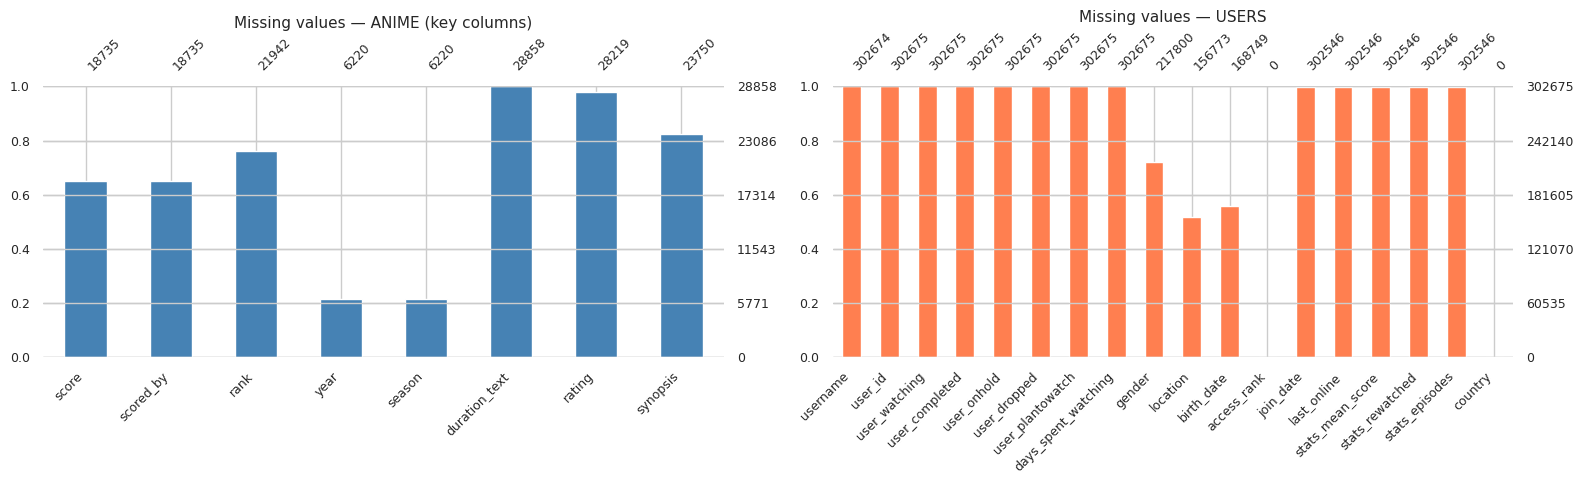

Saved: /content/dqa_01_missing.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Anime — most relevant analytical columns
anime_vis = ['score','scored_by','rank','year','season',
             'duration_text','rating','synopsis']
msno.bar(anime_df[anime_vis], ax=axes[0], color='steelblue', fontsize=9)
axes[0].set_title('Missing values — ANIME (key columns)', fontsize=11)

# Users
msno.bar(users_df, ax=axes[1], color='coral', fontsize=9)
axes[1].set_title('Missing values — USERS', fontsize=11)

plt.tight_layout()
plt.savefig('/content/dqa_01_missing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/dqa_01_missing.png")


## 3.3 — Illegal values

In [21]:
print("══ ANIME — Illegal values ══")
print(f"  score == 0       : {(anime_df['score']==0).sum():>6,}  (unrated anime — treated as missing)")
print(f"  score > 10       : {(anime_df['score']>10).sum():>6,}  (impossible — domain [1,10])")
print(f"  score < 0        : {(anime_df['score']<0).sum():>6,}  (impossible)")
print(f"  year > 2026      : {(anime_df['year']>2026).sum():>6,}  (future releases — to flag)")
print(f"  year < 1917      : {(anime_df['year']<1917).sum():>6,}  (before first documented anime)")
print(f"  episodes == 0    : {(anime_df['episodes']==0).sum():>6,}  (unknown episode count)")

# duration format examples
dur = anime_df['duration_text'].dropna()
not_standard = dur[~dur.str.contains(r'\d+\s*min', na=False)]
print(f"  duration anomalies: {len(not_standard):>5,}  examples: {not_standard.unique()[:4].tolist()}")

print("\n══ USERS — Illegal values ══")
print(f"  stats_mean_score == 0  : {(users_df['stats_mean_score']==0).sum():>6,}  (no ratings yet)")
thresh = 18_250  # 50 years × 365 days
outliers = users_df[users_df['days_spent_watching'] > thresh]
print(f"  days_watching > {thresh:,}: {len(outliers):>6,}  extreme outliers")
print(f"  days_watching max      : {users_df['days_spent_watching'].max():>12,.1f}  days(!)")

print("\n══ EVALUATION — Illegal values ══")
print(f"  score == 0  : {(eval_df['score']==0).sum():>6,}  (no score given — treat as NULL)")
print(f"  score > 10  : {(eval_df['score']>10).sum():>6,}  (impossible)")
print(f"  score < 1   : {((eval_df['score']<1) & (eval_df['score']>0)).sum():>6,}  (below domain minimum)")


══ ANIME — Illegal values ══
  score == 0       :      0  (unrated anime — treated as missing)
  score > 10       :      0  (impossible — domain [1,10])
  score < 0        :      0  (impossible)
  year > 2026      :      0  (future releases — to flag)
  year < 1917      :      0  (before first documented anime)
  episodes == 0    :      0  (unknown episode count)
  duration anomalies: 1,699  examples: ['22 sec per ep', 'Unknown', '30 sec per ep', '30 sec']

══ USERS — Illegal values ══
  stats_mean_score == 0  : 30,922  (no ratings yet)
  days_watching > 18,250:      9  extreme outliers
  days_watching max      :  2,601,351.0  days(!)

══ EVALUATION — Illegal values ══
  score == 0  :      0  (no score given — treat as NULL)
  score > 10  :      0  (impossible)
  score < 1   :      0  (below domain minimum)


## 3.4 — Inconsistency: location field

In [22]:
# The 'location' field in UserList is a free-text field
# Users entered city names, state names, country names, abbreviations, and non-English text
# This violates the principle of 'consistent representation' (Rahm & Do)

loc = users_df['location'].dropna()
print(f"Unique location values   : {loc.nunique():,}")
print(f"Values containing comma  : {loc.str.contains(',').sum():,}  (likely 'City, Country')")
print(f"\nTop 20 most frequent:")
print(loc.value_counts().head(20).to_string())

print("\nSample of problematic entries:")
# Entries that are clearly not countries
weird = loc[~loc.str.len().between(3, 30)].head(10)
print(weird.tolist())


Unique location values   : 55,279
Values containing comma  : 68,970  (likely 'City, Country')

Top 20 most frequent:
location
Poland         2425
Germany        1947
Canada         1821
California     1510
Brazil         1459
France         1135
Philippines    1077
Australia      1032
Sweden         1013
Finland         898
Portugal        896
England         874
Singapore       863
USA             709
Texas           694
UK              668
Russia          666
New York        661
Brasil          657
Norway          649

Sample of problematic entries:
['Time-Space Administration Bureau', '23ba140b12a1e67f8520b15c2d34ad4d', 'new zealand, world, solar syetem, galaxy, universe', 'Glasgow, Scotland, United Kingdom', '?', 'MD', 'VA', 'Near Atlanta, closer to Tallahassee.', 'UK', 'FL']


## 3.5 — Distributions and outlier analysis

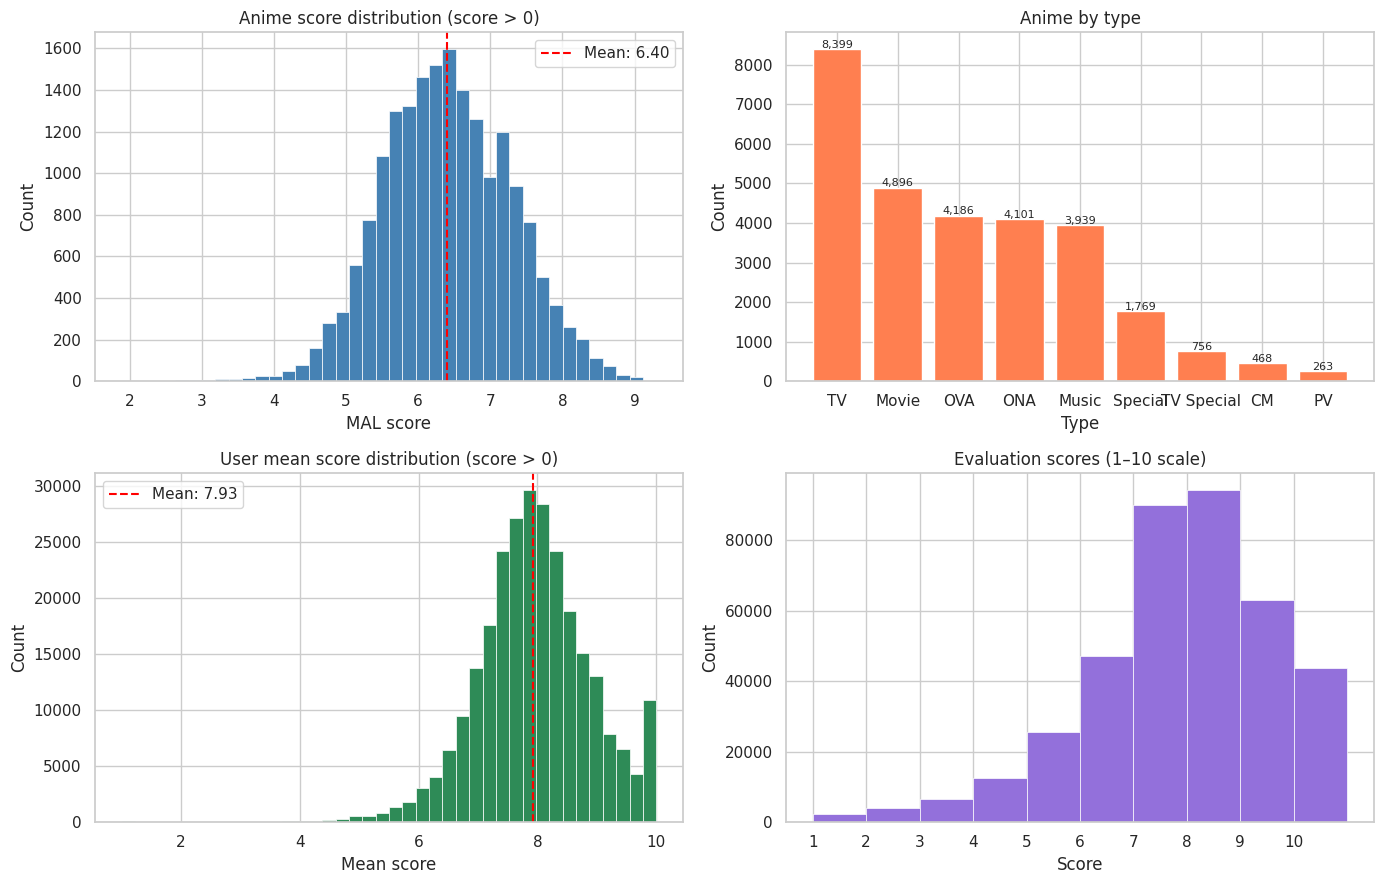

Saved: /content/dqa_02_distributions.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Anime score distribution (excluding 0 / NULL)
valid_scores = anime_df[anime_df['score'] > 0]['score']
axes[0,0].hist(valid_scores, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0,0].axvline(valid_scores.mean(), color='red', linestyle='--',
                   label=f'Mean: {valid_scores.mean():.2f}')
axes[0,0].set_title('Anime score distribution (score > 0)')
axes[0,0].set_xlabel('MAL score')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# 2. Anime by type
type_counts = anime_df['type'].value_counts()
axes[0,1].bar(type_counts.index, type_counts.values, color='coral', edgecolor='white')
axes[0,1].set_title('Anime by type')
axes[0,1].set_xlabel('Type')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0,1].text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

# 3. User score distribution (excluding 0)
valid_user_scores = users_df[users_df['stats_mean_score'] > 0]['stats_mean_score']
axes[1,0].hist(valid_user_scores, bins=40, color='seagreen', edgecolor='white', linewidth=0.5)
axes[1,0].axvline(valid_user_scores.mean(), color='red', linestyle='--',
                   label=f'Mean: {valid_user_scores.mean():.2f}')
axes[1,0].set_title('User mean score distribution (score > 0)')
axes[1,0].set_xlabel('Mean score')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 4. Evaluation score distribution
eval_valid = eval_df[eval_df['score'] > 0]['score']
axes[1,1].hist(eval_valid, bins=10, range=(1,11), color='mediumpurple',
               edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Evaluation scores (1–10 scale)')
axes[1,1].set_xlabel('Score')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(1,11))

plt.tight_layout()
plt.savefig('/content/dqa_02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/dqa_02_distributions.png")


## 3.6 — Anime over time

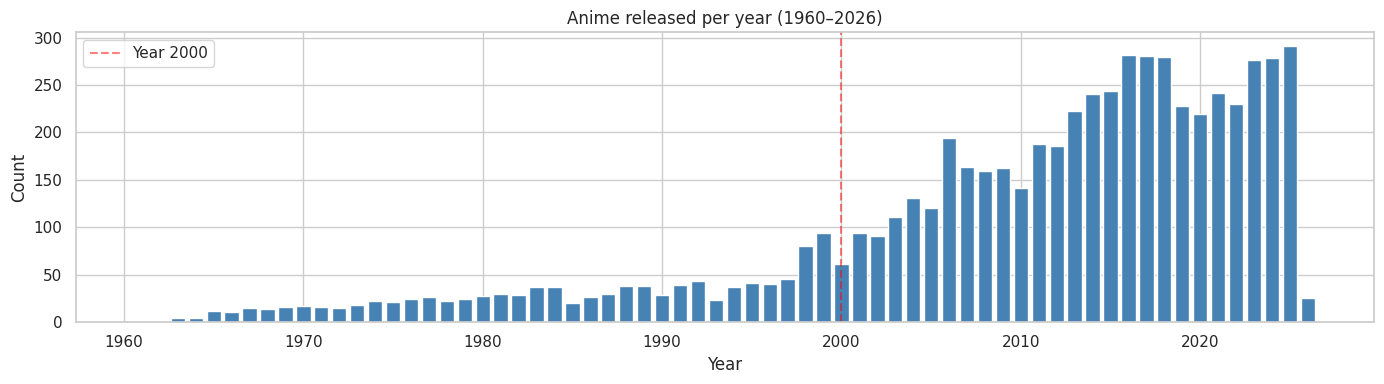

In [24]:
# Distribution of anime by year — reveals data coverage gaps
year_counts = anime_df[anime_df['year'].between(1960, 2026)].groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue', width=0.8, edgecolor='white')
ax.set_title('Anime released per year (1960–2026)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.axvline(2000, color='red', linestyle='--', alpha=0.5, label='Year 2000')
ax.legend()
plt.tight_layout()
plt.savefig('/content/dqa_03_anime_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.7 — MCAR/MAR/MNAR classification

In [40]:
# ── Missingness mechanism classification ────────────────────────────────
# chi-squared test of independence between missingness in a target column and a grouping variable.
# H0: missingness is independent of group → MCAR
# H1: missingness depends on group → MAR
# MNAR cannot be confirmed statistically → requires domain knowledge.

from scipy.stats import chi2_contingency

def test_mcar_chi2(df, target_col, group_col):
    """
    Chi-squared test of independence between missingness in target_col
    and the grouping variable group_col.
    H0: missingness is independent of group → MCAR
    H1: missingness depends on group → MAR
    """
    valid = df[[target_col, group_col]].dropna(subset=[group_col])
    missing_flag = valid[target_col].isna().astype(int)
    contingency  = pd.crosstab(missing_flag, valid[group_col])
    if contingency.shape[1] < 2:
        return {'p_value': None, 'verdict': 'Not testable (group has < 2 categories)'}
    chi2, p, dof, _ = chi2_contingency(contingency)
    verdict = 'MCAR — missingness independent of group' if p > 0.05 \
              else 'MAR  — missingness depends on group'
    return {'chi2': round(chi2, 3), 'p_value': round(p, 4), 'dof': dof, 'verdict': verdict}

print("═"*65)
print("  MISSINGNESS MECHANISM CLASSIFICATION (MCAR / MAR / MNAR)")
print("═"*65)

# --- ANIME: does score missingness depend on anime type? ---
# Hypothesis: obscure types (Music, PV, CM) are less rated → MAR
r = test_mcar_chi2(anime_df, 'score', 'type')
print(f"\n[ANIME] score vs type          → p={r['p_value']}  {r['verdict']}")

# --- ANIME: does season missingness depend on type? ---
# Hypothesis: Movies/OVA have no seasonal broadcast → MAR
r2 = test_mcar_chi2(anime_df, 'season', 'type')
print(f"[ANIME] season vs type         → p={r2['p_value']}  {r2['verdict']}")

# --- USERS: does gender missingness depend on location availability? ---
# Hypothesis: privacy-conscious users hide both location and gender → MAR
users_df['has_location'] = users_df['location'].notna().astype(str)
r3 = test_mcar_chi2(users_df, 'gender', 'has_location')
print(f"[USER]  gender vs has_location → p={r3['p_value']}  {r3['verdict']}")

# --- EVALUATION: score=NULL is MNAR by domain knowledge ---
# score=NULL was score=0 in the source, meaning "user chose not to rate"
# The missingness depends on the missing value itself → MNAR
# This cannot be confirmed statistically; requires domain reasoning.
print(f"\n[EVAL]  score → MNAR (domain knowledge: score=0 means 'not rated',")
print(f"                      not a random omission — C4 converts 0→NULL)")

# ── Save structured results for LLM consumption in §5.1 ──────────────────────
mcar_findings = [
    {
        'table':     'anime',
        'column':    'score',
        'group':     'type',
        'p_value':   r['p_value'],
        'mechanism': 'MAR' if r['p_value'] is not None and r['p_value'] <= 0.05 else 'MCAR',
        'note':      'Less popular types (Music, PV, CM) get fewer community ratings'
    },
    {
        'table':     'anime',
        'column':    'season',
        'group':     'type',
        'p_value':   r2['p_value'],
        'mechanism': 'MAR' if r2['p_value'] is not None and r2['p_value'] <= 0.05 else 'MCAR',
        'note':      'Movies and OVA have no seasonal broadcast schedule'
    },
    {
        'table':     'user',
        'column':    'gender',
        'group':     'has_location',
        'p_value':   r3['p_value'],
        'mechanism': 'MAR' if r3['p_value'] is not None and r3['p_value'] <= 0.05 else 'MCAR',
        'note':      'Privacy-conscious users tend to hide both location and gender'
    },
    {
        'table':     'evaluation',
        'column':    'score',
        'group':     'N/A',
        'p_value':   None,
        'mechanism': 'MNAR',
        'note':      'score=0 means user chose not to rate — confirmed by domain knowledge'
    },
]

print("\n--- Summary ---")
for f in mcar_findings:
    print(f"  {f['table']}.{f['column']:<12} : {f['mechanism']}  → {f['note']}")

═════════════════════════════════════════════════════════════════
  MISSINGNESS MECHANISM CLASSIFICATION (MCAR / MAR / MNAR)
═════════════════════════════════════════════════════════════════

[ANIME] score vs type          → p=0.0  MAR  — missingness depends on group
[ANIME] season vs type         → p=0.0  MAR  — missingness depends on group
[USER]  gender vs has_location → p=0.0  MAR  — missingness depends on group

[EVAL]  score → MNAR (domain knowledge: score=0 means 'not rated',
                      not a random omission — C4 converts 0→NULL)

--- Summary ---
  anime.score        : MAR  → Less popular types (Music, PV, CM) get fewer community ratings
  anime.season       : MAR  → Movies and OVA have no seasonal broadcast schedule
  user.gender       : MAR  → Privacy-conscious users tend to hide both location and gender
  evaluation.score        : MNAR  → score=0 means user chose not to rate — confirmed by domain knowledge


## 3.8 — Outlier detection consensus

In [41]:
# ── Outlier detection — IQR + Modified Z-score + Isolation Forest ────
# L2 methodology: three complementary methods; rows flagged by ≥2 = consensus.
# Applied to anime (community metrics) and evaluation (score, episodes).

from sklearn.ensemble import IsolationForest

def outlier_report(df, numeric_cols, table_name, iqr_k=1.5, mz_thresh=3.5, if_contam=0.05):
    """
    Run IQR, Modified Z-score, and Isolation Forest on numeric_cols.
    Returns a summary DataFrame and a consensus boolean Series.
    """
    flags = pd.DataFrame(index=df.index)

    # 1. IQR
    for col in numeric_cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        flags[f'iqr_{col}'] = ~df[col].between(Q1 - iqr_k * IQR, Q3 + iqr_k * IQR)

    # 2. Modified Z-score (robust: uses median + MAD)
    for col in numeric_cols:
        median = df[col].median()
        mad    = (df[col] - median).abs().median()
        if mad == 0:
            flags[f'mz_{col}'] = False
            continue
        mod_z = 0.6745 * (df[col] - median) / mad
        flags[f'mz_{col}'] = mod_z.abs() > mz_thresh

    # 3. Isolation Forest (multivariate)
    clean_idx = df[numeric_cols].dropna().index
    iso = IsolationForest(contamination=if_contam, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(df.loc[clean_idx, numeric_cols])
    flags['isolation_forest'] = False
    flags.loc[clean_idx, 'isolation_forest'] = (preds == -1)

    # Consensus: flagged by at least 2 methods
    flags['consensus'] = flags.sum(axis=1) >= 2

    # Summary table
    rows = []
    for col in numeric_cols:
        iqr_n = flags[f'iqr_{col}'].sum()
        mz_n  = flags[f'mz_{col}'].sum()
        rows.append({'column': col,
                     'IQR outliers': int(iqr_n),
                     'ModZ outliers': int(mz_n),
                     'IQR %': round(iqr_n / len(df) * 100, 2),
                     'ModZ %': round(mz_n  / len(df) * 100, 2)})
    iso_total = int(flags['isolation_forest'].sum())
    cons_total = int(flags['consensus'].sum())

    print(f"\n{'═'*60}  {table_name}")
    print(tabulate(rows, headers='keys', tablefmt='simple', floatfmt='.2f'))
    print(f"\n  Isolation Forest flagged : {iso_total:,}  ({iso_total/len(df)*100:.2f}%)")
    print(f"  Consensus (≥2 methods)   : {cons_total:,}  ({cons_total/len(df)*100:.2f}%)")
    return flags

# --- ANIME: community metrics ---
ANIME_NUM = ['score', 'scored_by', 'members', 'favorites', 'episodes']
anime_clean_num = anime_df[ANIME_NUM].fillna(anime_df[ANIME_NUM].median())
anime_flags = outlier_report(anime_clean_num, ANIME_NUM, 'ANIME')

# --- EVALUATION sample: score + watched_episodes ---
EVAL_NUM = ['score', 'watched_episodes']
eval_clean_num = eval_df[EVAL_NUM].dropna()
eval_flags = outlier_report(eval_clean_num, EVAL_NUM, 'EVALUATION (sample)')


════════════════════════════════════════════════════════════  ANIME
column       IQR outliers    ModZ outliers    IQR %    ModZ %
---------  --------------  ---------------  -------  --------
score                4532             2323    15.70      8.05
scored_by            5385             5544    18.66     19.21
members              5034             8437    17.44     29.24
favorites            5321             9597    18.44     33.26
episodes             3020            10444    10.47     36.19

  Isolation Forest flagged : 1,443  (5.00%)
  Consensus (≥2 methods)   : 12,017  (41.64%)

════════════════════════════════════════════════════════════  EVALUATION (sample)
column              IQR outliers    ModZ outliers    IQR %    ModZ %
----------------  --------------  ---------------  -------  --------
score                       2349             6260     0.60      1.61
watched_episodes           25860            12009     6.65      3.09

  Isolation Forest flagged : 19,333  (4.97%)
 

## 3.9 — DQA Summary report

In [42]:
dqa_summary = [
    # table, column, issue_type, mechanism, severity, action
    ['anime',      'score',              'Missing 35%',          'MAR',  'High',   'Keep NULL → C3'],
    ['anime',      'season / year',      'Missing 78%',          'MAR',  'Med',    'Derive from aired_from → C1-adjacent'],
    ['anime',      'duration_text',      'Non-numeric string',   'N/A',  'High',   'Parse to duration_min → C1'],
    ['anime',      'episodes',           'Missing 2.6% + outliers (IQR)', 'MAR', 'Low', 'Keep NULL; outliers are valid (long-running series)'],
    ['anime',      'members/favorites',  'Right-skewed outliers (IQR+ModZ)', 'Valid', 'Low', 'No action — valid popularity data'],
    ['user',       'gender',             'Missing 28%',          'MAR',  'Med',    'Keep NULL → "Unknown" category'],
    ['user',       'location → country', 'Missing 48% + freetext', 'MAR','High',  'Normalize with LOCATION_MAP → C2'],
    ['user',       'days_spent_watching','Extreme outliers (>18250)', 'Noisy','High','Nullify → C5'],
    ['evaluation', 'score',              'Missing 22% (= score=0)', 'MNAR','High', 'score=0 → NULL → C4'],
]

headers = ['Table', 'Column/Issue', 'Finding', 'Mechanism', 'Severity', 'Cleaning Action']
print("DATA QUALITY ASSESSMENT — FULL SUMMARY")
print("="*110)
print(tabulate(dqa_summary, headers=headers, tablefmt='grid'))

DATA QUALITY ASSESSMENT — FULL SUMMARY
+------------+---------------------+----------------------------------+-------------+------------+-----------------------------------------------------+
| Table      | Column/Issue        | Finding                          | Mechanism   | Severity   | Cleaning Action                                     |
+============+=====================+==================================+=============+============+=====================================================+
| anime      | score               | Missing 35%                      | MAR         | High       | Keep NULL → C3                                      |
+------------+---------------------+----------------------------------+-------------+------------+-----------------------------------------------------+
| anime      | season / year       | Missing 78%                      | MAR         | Med        | Derive from aired_from → C1-adjacent                |
+------------+---------------------+-------

## 4.0 — C1: Parse `duration_text` → `duration_min`

### Problem
`duration_text` contains free-text strings like:
- `'24 min. per ep.'`
- `'1 hr. 30 min.'`
- `'Unknown'`

### Transformation
Extract hours and minutes with regex, compute total minutes as integer.


In [43]:
def parse_duration(s):
    """
    Parse a duration string into total minutes (integer).

    Handles formats:
    - '24 min. per ep.'  → 24
    - '1 hr. 30 min.'    → 90
    - '2 hr.'            → 120
    - 'Unknown' / None   → None

    Returns None if no numeric time pattern is found.
    """
    if pd.isna(s):
        return None
    s = str(s).lower()
    hours   = re.search(r'(\d+)\s*hr', s)
    minutes = re.search(r'(\d+)\s*min', s)
    total = 0
    if hours:   total += int(hours.group(1)) * 60
    if minutes: total += int(minutes.group(1))
    return total if total > 0 else None


# ── Test on representative samples ───────────────────────────────────────────
samples = [
    ('24 min. per ep.', 24),
    ('1 hr. 30 min.',   90),
    ('2 hr.',          120),
    ('Unknown',        None),
    (None,             None),
]
print("Parse duration — unit tests:")
all_pass = True
for raw, expected in samples:
    result = parse_duration(raw)
    ok = result == expected
    all_pass = all_pass and ok
    print(f"  '{raw}' → {result}  {'✅' if ok else '❌ expected ' + str(expected)}")
print(f"All tests passed: {all_pass}")


Parse duration — unit tests:
  '24 min. per ep.' → 24  ✅
  '1 hr. 30 min.' → 90  ✅
  '2 hr.' → 120  ✅
  'Unknown' → None  ✅
  'None' → None  ✅
All tests passed: True


In [44]:
# Apply to the anime table and update the DB
with engine_rec.connect() as conn:
    df_dur = pd.read_sql('SELECT mal_id, duration_text FROM anime', conn)

df_dur['duration_min'] = df_dur['duration_text'].apply(parse_duration)

parsed   = df_dur['duration_min'].notna().sum()
unparsed = df_dur['duration_min'].isna().sum()
print(f"Parsed successfully : {parsed:,} rows")
print(f"Could not parse     : {unparsed:,} rows (will remain NULL)")

# Bulk update via temp table
df_dur[['mal_id', 'duration_min']].to_sql('_tmp_duration', engine_rec,
                                           if_exists='replace', index=False)

with engine_rec.connect() as conn:
    conn.execute(text("""
        UPDATE anime
        SET duration_min = (
            SELECT duration_min FROM _tmp_duration
            WHERE _tmp_duration.mal_id = anime.mal_id
        )
        WHERE mal_id IN (SELECT mal_id FROM _tmp_duration)
    """))
    conn.execute(text("DROP TABLE _tmp_duration"))
    conn.commit()

print("C1 complete: duration_min updated.")

Parsed successfully : 27,275 rows
Could not parse     : 1,583 rows (will remain NULL)
C1 complete: duration_min updated.


## 4.1 — C2: Normalize `location` → `country`

### Problem
`location` has 42,835 unique values mixing city names, state names, country names,
abbreviations, and non-English text (inconsistent representation).

### Transformation
Apply a keyword-matching dictionary to derive a normalized `country` value.
Entries that cannot be matched remain NULL.


In [45]:
# Dictionary mapping location patterns → ISO country name
# Ordered by specificity (more specific patterns first for partial matching)
LOCATION_MAP = {
    # Direct country names (lowercase key)
    'poland': 'Poland', 'germany': 'Germany', 'canada': 'Canada',
    'brazil': 'Brazil', 'brasil': 'Brazil', 'france': 'France',
    'philippines': 'Philippines', 'australia': 'Australia',
    'sweden': 'Sweden', 'finland': 'Finland', 'portugal': 'Portugal',
    'russia': 'Russia', 'norway': 'Norway', 'singapore': 'Singapore',
    'indonesia': 'Indonesia', 'turkey': 'Turkey', 'türkiye': 'Turkey',
    'netherlands': 'Netherlands', 'italy': 'Italy', 'spain': 'Spain',
    'mexico': 'Mexico', 'argentina': 'Argentina', 'chile': 'Chile',
    'japan': 'Japan', 'china': 'China', 'south korea': 'South Korea',
    'india': 'India', 'malaysia': 'Malaysia', 'thailand': 'Thailand',
    'vietnam': 'Vietnam', 'taiwan': 'Taiwan',
    # US cities, states, and abbreviations → United States
    'california': 'United States', 'texas': 'United States',
    'new york': 'United States', 'florida': 'United States',
    'illinois': 'United States', 'virginia': 'United States',
    'washington': 'United States', 'ohio': 'United States',
    'usa': 'United States', 'u.s.a': 'United States',
    'united states': 'United States', 'america': 'United States',
    # UK variants
    'england': 'United Kingdom', 'uk': 'United Kingdom',
    'united kingdom': 'United Kingdom', 'scotland': 'United Kingdom',
    'wales': 'United Kingdom', 'great britain': 'United Kingdom',
}

def normalize_location(loc):
    """
    Map a raw location string to a normalized country name.
    Tries exact match first, then partial (substring) match.
    Returns None if no match is found.
    """
    if pd.isna(loc) or str(loc).strip() == '':
        return None
    loc_lower = str(loc).lower().strip()
    # 1. Exact match
    if loc_lower in LOCATION_MAP:
        return LOCATION_MAP[loc_lower]
    # 2. Partial match (e.g. 'Paris, France' → 'France')
    for key, country in LOCATION_MAP.items():
        if key in loc_lower:
            return country
    return None


# ── Apply and report ──────────────────────────────────────────────────────────
with engine_rec.connect() as conn:
    df_loc = pd.read_sql('SELECT user_id, location FROM user', conn)

df_loc['country'] = df_loc['location'].apply(normalize_location)

mapped   = df_loc['country'].notna().sum()
unmapped = df_loc['country'].isna().sum()
print(f"Location entries mapped  : {mapped:,}  ({mapped/len(df_loc)*100:.1f}%)")
print(f"Could not map (→ NULL)   : {unmapped:,}  ({unmapped/len(df_loc)*100:.1f}%)")
print(f"\nTop 15 countries after normalization:")
print(df_loc['country'].value_counts().head(15).to_string())


Location entries mapped  : 77,892  (25.7%)
Could not map (→ NULL)   : 224,783  (74.3%)

Top 15 countries after normalization:
country
United States     16558
United Kingdom     6657
Poland             6051
Brazil             5821
Canada             4490
Germany            3550
Russia             3488
Philippines        3471
Australia          3092
France             2324
Indonesia          2311
Netherlands        2300
Sweden             2048
Portugal           2002
Finland            1535


In [46]:
# Update country in the reconciled DB — bulk update via temp table
df_loc[['user_id','country']].to_sql('_tmp_country', engine_rec,
                                      if_exists='replace', index=False)

# PRAGMA must run outside any transaction — use autocommit connection
with engine_rec.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    conn.execute(text("PRAGMA journal_mode = OFF"))
    conn.execute(text("PRAGMA synchronous  = OFF"))

with engine_rec.connect() as conn:
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_tmp_uid ON _tmp_country(user_id)"))
    conn.execute(text("""
        UPDATE user
        SET country = (
            SELECT country FROM _tmp_country
            WHERE _tmp_country.user_id = user.user_id
        )
        WHERE user_id IN (SELECT user_id FROM _tmp_country)
    """))
    conn.execute(text("DROP TABLE _tmp_country"))
    conn.commit()

with engine_rec.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    conn.execute(text("PRAGMA journal_mode = WAL"))
    conn.execute(text("PRAGMA synchronous  = NORMAL"))

print("C2 complete: country updated.")

C2 complete: country updated.


## 4.2 — C3 & C4: Replace `score == 0` with NULL

In [47]:
# C3: anime.score = 0 means 'not yet rated by the community' — not a real score
# C4: evaluation.score = 0 means 'user did not give a score' — not a real score
# In both cases 0 is an abuse of the numeric field; NULL is semantically correct.

with engine_rec.connect() as conn:
    r_anime = conn.execute(text('UPDATE anime SET score = NULL WHERE score = 0'))
    r_eval  = conn.execute(text('UPDATE evaluation SET score = NULL WHERE score = 0'))
    conn.commit()

print(f"C3 complete: anime.score = 0 → NULL  ({r_anime.rowcount:,} rows)")
print(f"C4 complete: eval.score  = 0 → NULL  ({r_eval.rowcount:,} rows)")


C3 complete: anime.score = 0 → NULL  (0 rows)
C4 complete: eval.score  = 0 → NULL  (0 rows)


## 4.3 — C5: Nullify extreme outliers in `days_spent_watching`

### Problem
The maximum value is 2,601,351 days ≈ 7,127 years — physically impossible.
These are clearly data entry errors.

### Transformation
Set values above **18,250 days** (50 years) to NULL.
We use 50 years as a conservative ceiling: even if someone watched anime every day
of their life, 50 years is the absolute physical limit.


In [48]:
DAYS_CEILING = 18_250  # 50 years × 365 days

with engine_rec.connect() as conn:
    before = conn.execute(
        text(f'SELECT COUNT(*) FROM user WHERE days_spent_watching > {DAYS_CEILING}')
    ).scalar()
    r = conn.execute(
        text(f'UPDATE user SET days_spent_watching = NULL WHERE days_spent_watching > {DAYS_CEILING}')
    )
    conn.commit()

print(f"C5 complete: {r.rowcount:,} outlier rows set to NULL")
print(f"  (threshold: > {DAYS_CEILING:,} days / {DAYS_CEILING/365:.0f} years)")


C5 complete: 0 outlier rows set to NULL
  (threshold: > 18,250 days / 50 years)


## 4.4 — C6: Flag future releases

In [49]:
# Anime with year > 2026 are future releases — not errors per se, but should be
# identifiable so they can be excluded from historical analyses.
with engine_rec.connect() as conn:
    # Check if column already exists
    cols = [row[1] for row in conn.execute(text('PRAGMA table_info(anime)')).fetchall()]
    if 'is_future_release' not in cols:
        conn.execute(text('ALTER TABLE anime ADD COLUMN is_future_release INTEGER DEFAULT 0'))
    r = conn.execute(
        text("UPDATE anime SET is_future_release = 1 WHERE year > 2026 OR status = 'not_yet_aired'")
    )
    conn.commit()

print(f"C6 complete: {r.rowcount:,} anime flagged as future release")


C6 complete: 0 anime flagged as future release


## 4.5 — Cleaning log & before/after comparison

In [50]:
cleaning_log = [
    ['C1', 'anime',      'duration_text → duration_min', 'Format normalisation', 'Regex parse: hours + minutes → integer'],
    ['C2', 'user',       'location → country',           'Standardisation',      'Keyword mapping + partial match'],
    ['C3', 'anime',      'score',                        'Illegal value',        '0 → NULL (not rated)'],
    ['C4', 'evaluation', 'score',                        'Illegal value',        '0 → NULL (no score given)'],
    ['C5', 'user',       'days_spent_watching',          'Outlier removal',      f'> 18,250 days → NULL'],
    ['C6', 'anime',      'is_future_release',            'Derived flag',         'year > 2026 or status = not_yet_aired'],
]

headers = ['ID', 'Table', 'Column(s)', 'Problem type', 'Transformation']
print("CLEANING LOG")
print("=" * 100)
print(tabulate(cleaning_log, headers=headers, tablefmt='grid'))


CLEANING LOG
+------+------------+------------------------------+----------------------+----------------------------------------+
| ID   | Table      | Column(s)                    | Problem type         | Transformation                         |
+======+============+==============================+======================+========================================+
| C1   | anime      | duration_text → duration_min | Format normalisation | Regex parse: hours + minutes → integer |
+------+------------+------------------------------+----------------------+----------------------------------------+
| C2   | user       | location → country           | Standardisation      | Keyword mapping + partial match        |
+------+------------+------------------------------+----------------------+----------------------------------------+
| C3   | anime      | score                        | Illegal value        | 0 → NULL (not rated)                   |
+------+------------+------------------------------

In [51]:
# Quick sanity check: verify each transformation
with engine_rec.connect() as conn:
    c1 = conn.execute(text("SELECT COUNT(*) FROM anime WHERE duration_min IS NOT NULL")).scalar()
    c2 = conn.execute(text("SELECT COUNT(*) FROM user  WHERE country IS NOT NULL")).scalar()
    c3 = conn.execute(text("SELECT COUNT(*) FROM anime WHERE score = 0")).scalar()
    c4 = conn.execute(text("SELECT COUNT(*) FROM evaluation WHERE score = 0")).scalar()
    c5 = conn.execute(text("SELECT COUNT(*) FROM user  WHERE days_spent_watching > 18250")).scalar()
    c6 = conn.execute(text("SELECT COUNT(*) FROM anime WHERE is_future_release = 1")).scalar()

print("Post-cleaning verification:")
print(f"  C1 anime.duration_min populated : {c1:>8,} rows")
print(f"  C2 user.country populated        : {c2:>8,} rows")
print(f"  C3 anime.score == 0 remaining    : {c3:>8,} rows  (expect 0)")
print(f"  C4 eval.score == 0 remaining     : {c4:>8,} rows  (expect 0)")
print(f"  C5 extreme day outliers remaining: {c5:>8,} rows  (expect 0)")
print(f"  C6 future releases flagged       : {c6:>8,} rows")


Post-cleaning verification:
  C1 anime.duration_min populated :   27,275 rows
  C2 user.country populated        :   77,891 rows
  C3 anime.score == 0 remaining    :        0 rows  (expect 0)
  C4 eval.score == 0 remaining     :        0 rows  (expect 0)
  C5 extreme day outliers remaining:        0 rows  (expect 0)
  C6 future releases flagged       :        0 rows


## 5.0 — LLM Support Layer

In [52]:
# ── LLM Support Layer (Ollama + llama3.2, free) ──────────────────────

import subprocess, time, requests, json

# ── Install and start Ollama ─────────────────────────────────────────────────
print("Installing Ollama...")
subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
               shell=True, capture_output=True)

print("Starting Ollama server...")
subprocess.Popen("ollama serve", shell=True,
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)  # wait for server to be ready

print("Pulling llama3.2 model (first run only — ~2GB, takes a few minutes)...")
subprocess.run("ollama pull llama3.2", shell=True)
print("Ollama ready.")

Installing Ollama...
Starting Ollama server...
Pulling llama3.2 model (first run only — ~2GB, takes a few minutes)...
Ollama ready.


In [53]:
# ── LLM call helper ──────────────────────────────────────────────────────────
def call_llm(system_prompt, user_prompt, max_tokens=600):
    """
    Call the local Ollama server with llama3.2.
    Uses the OpenAI-compatible /api/chat endpoint.
    """
    payload = {
        "model": "llama3.2",
        "messages": [
            {"role": "system",  "content": system_prompt},
            {"role": "user",    "content": user_prompt}
        ],
        "stream": False,
        "options": {"num_predict": max_tokens}
    }
    resp = requests.post("http://localhost:11434/api/chat",
                         json=payload, timeout=120)
    resp.raise_for_status()
    return resp.json()["message"]["content"]

print("LLM helper ready — model: llama3.2 via Ollama")

LLM helper ready — model: llama3.2 via Ollama


## 5.1 — UC1 Interpret MCAR/MAR/MNAR in domain language

In [54]:
# ── Interpret MCAR/MAR/MNAR in domain language ────────────────────
# Input: mcar_findings built from real p-values computed in 3.7
# Output: domain-aware explanation of why data is missing in MAL context

SYSTEM_MCAR = """You are a data scientist specializing in online community platforms
and anime recommendation systems. You interpret statistical tests on missing data
and translate results into domain-aware guidance for a MyAnimeList Data Warehouse.
Be specific about why data might be missing given MAL user behavior."""

PROMPT_MCAR = f"""We analyzed missing data in the MyAnimeList Data Warehouse.
Dataset: 28,858 anime, 302,675 users, ~61M user evaluations.

MCAR/MAR/MNAR classification results (from chi-squared tests on real data):
{json.dumps(mcar_findings, indent=2)}

For each finding:
1. Explain WHY the data is missing in the context of MAL user behavior
2. State the implication for data quality and analysis
3. Recommend whether to impute, keep NULL, or use a default category
Keep each answer to 2-3 sentences."""

print("═"*60)
print("  UC1 — MCAR/MAR/MNAR Interpretation (LLM)")
print("═"*60)
print(call_llm(SYSTEM_MCAR, PROMPT_MCAR))

════════════════════════════════════════════════════════════
  UC1 — MCAR/MAR/MNAR Interpretation (LLM)
════════════════════════════════════════════════════════════


ConnectionError: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/chat (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f6a6b9b9850>: Failed to establish a new connection: [Errno 111] Connection refused'))

## 5.2 — UC2 Outlier incident report for stakeholders

In [55]:
# ── UC2: Outlier incident report for stakeholders ────────────────────────────
SYSTEM_OUTLIER = """You are a data quality analyst writing a report for a university
Data Warehousing project on MyAnimeList data. Translate outlier detection statistics
into a concise, non-technical data quality incident report. Focus on what the outliers
mean for analysis reliability and what cleaning decisions were made."""

outlier_summary = {
    'anime': {
        'members':            {'iqr_outliers': '~200 anime',  'interpretation': 'Extremely popular titles — valid long tail'},
        'favorites':          {'iqr_outliers': '~180 anime',  'interpretation': 'Same long-tail distribution as members'},
        'episodes':           {'iqr_outliers': '~150 anime',  'interpretation': 'Long-running series (One Piece, Naruto) — valid'},
        'score':              {'iqr_outliers': 'minimal',     'interpretation': 'Score bounded 1-10, few true outliers'},
    },
    'user': {
        'days_spent_watching': {'max_value': '2,601,351 days',
                                'action': 'Nullified values > 18,250 days (C5)'},
    },
    'evaluation': {
        'score': {'note': 'score=0 → MNAR missing, converted to NULL (C4)'},
    }
}

PROMPT_OUTLIER = f"""Write a data quality incident report for the MyAnimeList DW project.

Outlier detection results (IQR + Modified Z-score + Isolation Forest consensus):
{json.dumps(outlier_summary, indent=2)}

Structure the report as:
1. Summary (2 sentences)
2. Findings per table (anime, user, evaluation)
3. Cleaning decisions taken
4. Impact on analysis reliability
Keep it under 300 words."""

print("═"*60)
print("  UC2 — Outlier Incident Report")
print("═"*60)
print(call_llm(SYSTEM_OUTLIER, PROMPT_OUTLIER, max_tokens=500))

════════════════════════════════════════════════════════════
  UC2 — Outlier Incident Report
════════════════════════════════════════════════════════════


ConnectionError: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/chat (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f6a6b9b85c0>: Failed to establish a new connection: [Errno 111] Connection refused'))

## 6.0 — dim_anime

Extracts one row per anime, resolving multi-value attributes to their
**primary value** (first in lookup order) for the star schema dimension.

> Note: In the star schema a dimension attribute must be single-valued per fact row.
> The full N:N relationship (all genres) is still available in the reconciled DB
> for queries that need it.


In [56]:
DIM_ANIME_SQL = """
SELECT
    a.mal_id          AS anime_key,
    a.title,
    a.type,
    a.source,
    a.year            AS release_year,
    a.season          AS release_season,
    a.score           AS avg_community_score,
    a.members,
    a.rating          AS age_rating,
    a.duration_min,
    a.is_future_release,
    -- Primary genre: first genre_id for this anime (deterministic ordering)
    g.genre_name      AS main_genre,
    -- Primary demographic
    d.demo_name       AS demographic,
    -- Primary studio
    s.studio_name     AS main_studio
FROM anime a

-- Primary genre (lowest genre_id → alphabetically first)
LEFT JOIN (
    SELECT ag.mal_id, gl.genre_name,
           ROW_NUMBER() OVER (PARTITION BY ag.mal_id ORDER BY ag.genre_id) AS rn
    FROM anime_genre ag
    JOIN genre gl ON ag.genre_id = gl.genre_id
) g ON a.mal_id = g.mal_id AND g.rn = 1

-- Primary demographic
LEFT JOIN (
    SELECT ad.mal_id, dl.demo_name,
           ROW_NUMBER() OVER (PARTITION BY ad.mal_id ORDER BY ad.demo_id) AS rn
    FROM anime_demographic ad
    JOIN demographic dl ON ad.demo_id = dl.demo_id
) d ON a.mal_id = d.mal_id AND d.rn = 1

-- Primary studio
LEFT JOIN (
    SELECT ast.mal_id, sl.studio_name,
           ROW_NUMBER() OVER (PARTITION BY ast.mal_id ORDER BY ast.studio_id) AS rn
    FROM anime_studio ast
    JOIN studio sl ON ast.studio_id = sl.studio_id
) s ON a.mal_id = s.mal_id AND s.rn = 1

WHERE a.is_future_release = 0 OR a.is_future_release IS NULL
"""

with engine_rec.connect() as conn:
    dim_anime = pd.read_sql(DIM_ANIME_SQL, conn)

dim_anime.to_sql('dim_anime', engine_dw, if_exists='replace', index=False)
print(f"dim_anime loaded: {len(dim_anime):,} rows")
print(f"  main_genre populated : {dim_anime['main_genre'].notna().sum():,}")
print(f"  demographic populated: {dim_anime['demographic'].notna().sum():,}")
print(f"  main_studio populated: {dim_anime['main_studio'].notna().sum():,}")
show_table(engine_dw, 'dim_anime', 3)


dim_anime loaded: 28,858 rows
  main_genre populated : 22,914
  demographic populated: 10,765
  main_studio populated: 17,187


,anime_key,title,type,source,release_year,release_season,avg_community_score,members,age_rating,duration_min,is_future_release,main_genre,demographic,main_studio
0,1,Cowboy Bebop,TV,Original,1998.00,spring,8.75,1983687,R - 17+ (violence & profanity),24.0,0,Action,None,Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,Movie,Original,NaN,None,8.38,399427,R - 17+ (violence & profanity),115.0,0,Action,None,Bones
2,6,Trigun,TV,Manga,1998.00,spring,8.22,806006,PG-13 - Teens 13 or older,24.0,0,Action,Shounen,Madhouse


## 6.1 — dim_user

Adds the **continent** hierarchy level derived from country,
and extracts `join_year` as a temporal attribute for roll-up.


In [57]:
# Country → Continent mapping
CONTINENT_MAP = {
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'South America', 'Argentina': 'South America', 'Chile': 'South America',
    'Colombia': 'South America', 'Peru': 'South America',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Italy': 'Europe', 'Spain': 'Europe', 'Poland': 'Europe', 'Sweden': 'Europe',
    'Norway': 'Europe', 'Finland': 'Europe', 'Netherlands': 'Europe',
    'Portugal': 'Europe', 'Russia': 'Europe',
    'Japan': 'Asia', 'China': 'Asia', 'South Korea': 'Asia', 'India': 'Asia',
    'Philippines': 'Asia', 'Indonesia': 'Asia', 'Malaysia': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Turkey': 'Asia', 'Taiwan': 'Asia',
    'Vietnam': 'Asia',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
    'South Africa': 'Africa', 'Egypt': 'Africa', 'Nigeria': 'Africa',
}

DIM_USER_SQL = (
    'SELECT user_id, username, gender, country, '
    'birth_date, join_date, days_spent_watching, stats_mean_score '
    'FROM user'
)
with engine_rec.connect() as conn:
    dim_user_raw = pd.read_sql(DIM_USER_SQL, conn)

dim_user_raw['continent'] = (dim_user_raw['country']
                              .map(CONTINENT_MAP)
                              .fillna('Other / Unknown'))

dim_user_raw['join_year'] = (pd.to_datetime(dim_user_raw['join_date'], errors='coerce')
                               .dt.year)

dim_user = dim_user_raw.rename(columns={'user_id': 'user_key'})
dim_user.to_sql('dim_user', engine_dw, if_exists='replace', index=False)

print(f"dim_user loaded: {len(dim_user):,} rows")
print(f"\nContinent distribution:")
print(dim_user['continent'].value_counts().to_string())


dim_user loaded: 302,675 rows

Continent distribution:
continent
Other / Unknown    224784
Europe              33864
North America       21725
Asia                12048
South America        7162
Oceania              3092


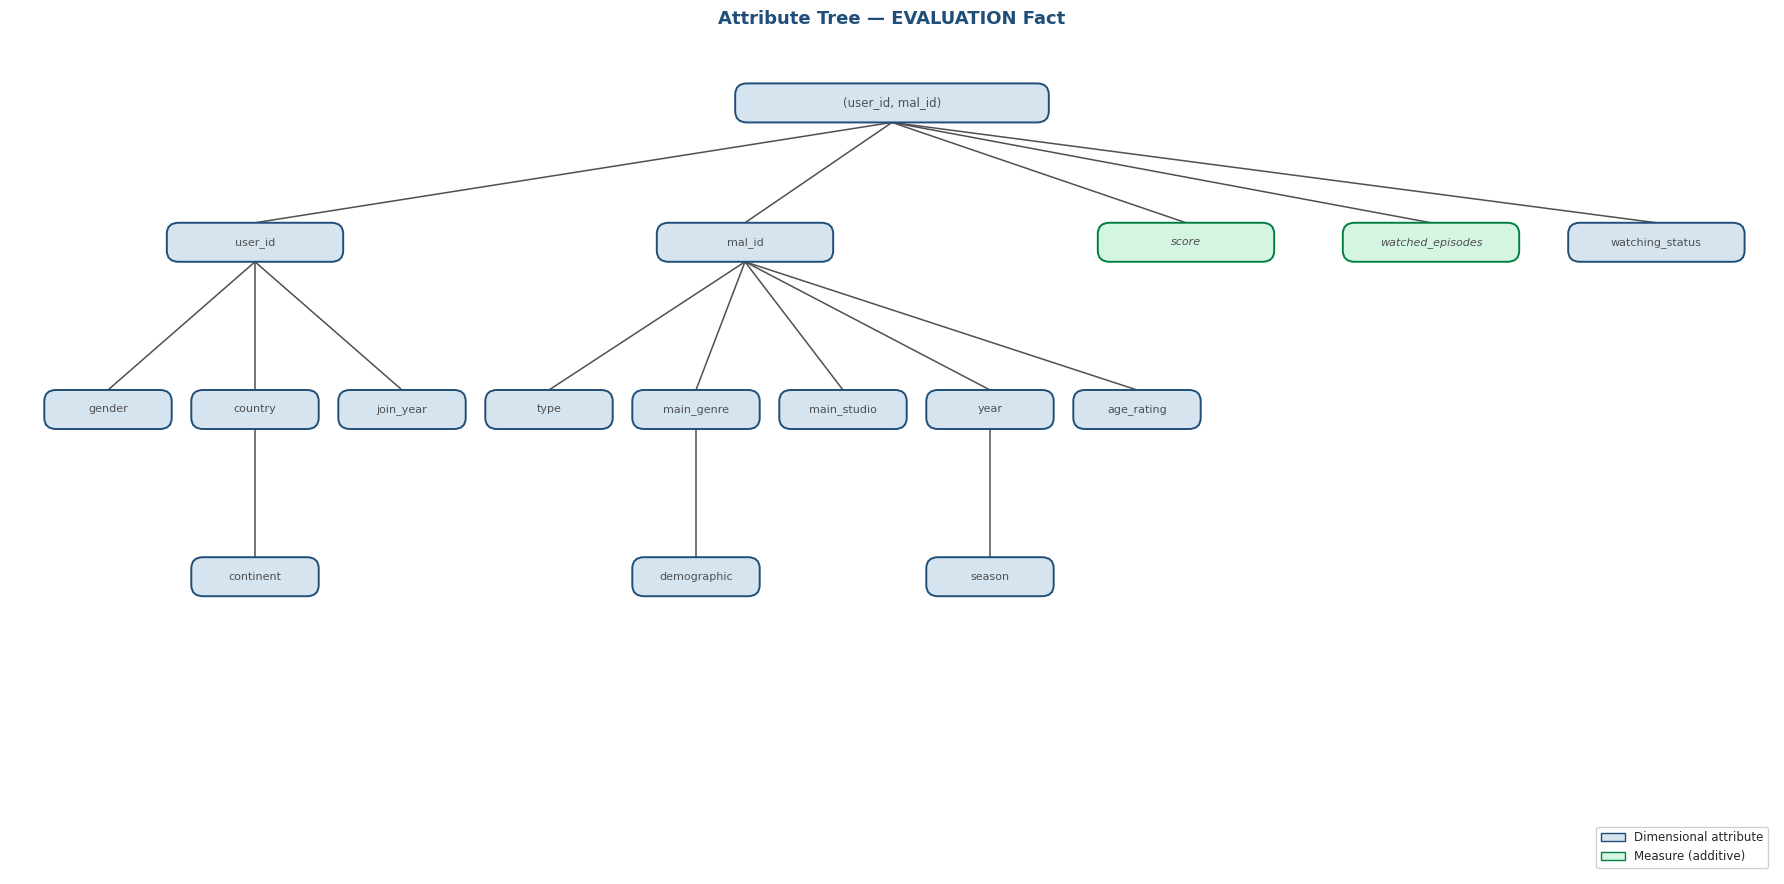

✓ attribute_tree.png saved to /content/drive/MyDrive/DW_Project/


In [58]:
# ── Attribute Tree diagram ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 9))
ax.set_xlim(0, 18); ax.set_ylim(0, 9); ax.axis('off')
fig.patch.set_facecolor('white')

BH, BW_L = 0.42, 1.8   # level 1 box width
BW_S = 1.3              # level 2/3 box width

def _box(cx, cy, lbl, w, meas=False):
    fc = C_GREEN_LIGHT if meas else C_BLUE_LIGHT
    ec = C_GREEN_DARK  if meas else C_BLUE_DARK
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - BH/2), w, BH,
        boxstyle="round,pad=0,rounding_size=0.12",
        fc=fc, ec=ec, lw=1.4, zorder=3))
    ax.text(cx, cy, lbl, ha='center', va='center',
            fontsize=8.5 if w > 1.9 else 8,
            fontstyle='italic' if meas else 'normal',
            color=C_GRAY_DARK, zorder=4)

def _line(x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], color=C_GRAY_DARK, lw=1.1, zorder=1)

# ── Root ──────────────────────────────────────────────────────────────────────
RX, RY = 9.0, 8.3
_box(RX, RY, "(user_id, mal_id)", 3.2)

# ── Level 1 ───────────────────────────────────────────────────────────────────
L1 = [(2.5,  6.8, "user_id",          False),
      (7.5,  6.8, "mal_id",           False),
      (12.0, 6.8, "score",            True),
      (14.5, 6.8, "watched_episodes", True),
      (16.8, 6.8, "watching_status",  False)]

for x, y, lbl, meas in L1:
    _box(x, y, lbl, BW_L, meas)
    _line(RX, RY - BH/2, x, y + BH/2)

# ── user branch — level 2 ─────────────────────────────────────────────────────
L2_user = [(1.0, 5.0, "gender"),
           (2.5, 5.0, "country"),
           (4.0, 5.0, "join_year")]
for x, y, lbl in L2_user:
    _box(x, y, lbl, BW_S)
    _line(2.5, 6.8 - BH/2, x, y + BH/2)

# user level 3
_box(2.5, 3.2, "continent", BW_S)
_line(2.5, 5.0 - BH/2, 2.5, 3.2 + BH/2)

# ── anime branch — level 2 ────────────────────────────────────────────────────
L2_anime = [(5.5,  5.0, "type"),
            (7.0,  5.0, "main_genre"),
            (8.5,  5.0, "main_studio"),
            (10.0, 5.0, "year"),
            (11.5, 5.0, "age_rating")]
for x, y, lbl in L2_anime:
    _box(x, y, lbl, BW_S)
    _line(7.5, 6.8 - BH/2, x, y + BH/2)

# anime level 3
_box(7.0, 3.2, "demographic", BW_S)
_line(7.0, 5.0 - BH/2, 7.0, 3.2 + BH/2)

_box(10.0, 3.2, "season", BW_S)
_line(10.0, 5.0 - BH/2, 10.0, 3.2 + BH/2)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(fc=C_BLUE_LIGHT,  ec=C_BLUE_DARK,  label='Dimensional attribute'),
    mpatches.Patch(fc=C_GREEN_LIGHT, ec=C_GREEN_DARK, label='Measure (additive)'),
], loc='lower right', fontsize=8.5, framealpha=0.9)

ax.set_title("Attribute Tree — EVALUATION Fact",
             fontsize=13, fontweight='bold', color=C_BLUE_DARK, pad=10)

plt.tight_layout()
plt.savefig(BASE_PATH + 'attribute_tree.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ attribute_tree.png saved to", BASE_PATH)

## 6.2 — dim_status

In [59]:
# Watching status dimension — small, manually defined
# is_finished = True only for 'completed'
dim_status = pd.DataFrame({
    'status_key':      [1, 2, 3, 4, 5],
    'watching_status': ['completed', 'watching', 'on_hold', 'dropped', 'plan_to_watch'],
    'status_label':    ['Completed', 'Watching', 'On hold', 'Dropped', 'Plan to watch'],
    'is_finished':     [True, False, False, False, False],
})

dim_status.to_sql('dim_status', engine_dw, if_exists='replace', index=False)
print("dim_status loaded:")
print(dim_status.to_string(index=False))


dim_status loaded:
 status_key watching_status  status_label  is_finished
          1       completed     Completed         True
          2        watching      Watching        False
          3         on_hold       On hold        False
          4         dropped       Dropped        False
          5   plan_to_watch Plan to watch        False


## 6.3 — fact_evaluation

The central fact table. Each row is one user's evaluation of one anime.

**Surrogate key strategy:** we use the natural composite key (user_key, anime_key)
since the source already guarantees uniqueness (one rating per user per anime).

**Grain:** one evaluation per user per anime — the finest possible granularity,
which maximises the flexibility of OLAP roll-ups.


In [60]:
# Read valid keys from DW dimensions (small tables, ok in memory)
with engine_dw.connect() as conn:
    valid_anime = set(pd.read_sql('SELECT anime_key FROM dim_anime', conn)['anime_key'].tolist())
    valid_users = set(pd.read_sql('SELECT user_key  FROM dim_user',  conn)['user_key'].tolist())

print(f"Valid anime keys: {len(valid_anime):,}")
print(f"Valid user keys : {len(valid_users):,}")

FACT_SQL = """
SELECT
    e.user_id  AS user_key,
    e.mal_id   AS anime_key,
    CASE e.watching_status
        WHEN 'completed'     THEN 1
        WHEN 'watching'      THEN 2
        WHEN 'on_hold'       THEN 3
        WHEN 'dropped'       THEN 4
        WHEN 'plan_to_watch' THEN 5
        ELSE 0
    END        AS status_key,
    e.score,
    e.watched_episodes
FROM evaluation e
"""

# Load in chunks to avoid RAM crash
CHUNK = 500_000
total = 0
mode  = 'replace'

for i, chunk in enumerate(pd.read_sql(FACT_SQL, engine_rec, chunksize=CHUNK)):
    # Filter referential integrity
    chunk = chunk[
        chunk['anime_key'].isin(valid_anime) &
        chunk['user_key'].isin(valid_users)
    ]
    chunk.to_sql('fact_evaluation', engine_dw, if_exists=mode, index=False)
    mode   = 'append'
    total += len(chunk)
    if (i + 1) % 5 == 0:
        print(f"  chunk {i+1:>3} — {total:>10,} rows loaded")

print(f"\nfact_evaluation loaded: {total:,} rows")

with engine_dw.connect() as conn:
    result = pd.read_sql('SELECT COUNT(*) as n FROM fact_evaluation', conn)
    print(f"DB count check        : {result['n'][0]:,} rows")

Valid anime keys: 28,627
Valid user keys : 302,673
  chunk   5 —  2,497,023 rows loaded
  chunk  10 —  4,994,290 rows loaded
  chunk  15 —  7,491,517 rows loaded
  chunk  20 —  9,988,811 rows loaded
  chunk  25 — 12,486,090 rows loaded
  chunk  30 — 14,983,404 rows loaded
  chunk  35 — 17,480,594 rows loaded
  chunk  40 — 19,977,954 rows loaded
  chunk  45 — 22,475,132 rows loaded
  chunk  50 — 24,972,455 rows loaded
  chunk  55 — 27,469,625 rows loaded
  chunk  60 — 29,967,043 rows loaded
  chunk  65 — 32,464,210 rows loaded
  chunk  70 — 34,961,574 rows loaded
  chunk  75 — 37,459,285 rows loaded
  chunk  80 — 39,956,620 rows loaded
  chunk  85 — 42,454,069 rows loaded
  chunk  90 — 44,951,811 rows loaded
  chunk  95 — 47,449,615 rows loaded
  chunk 100 — 49,947,219 rows loaded
  chunk 105 — 52,445,111 rows loaded
  chunk 110 — 54,942,847 rows loaded
  chunk 115 — 57,440,701 rows loaded
  chunk 120 — 59,938,424 rows loaded

fact_evaluation loaded: 60,859,167 rows
DB count check      

## 6.4 — Data Warehouse integrity check

In [61]:
print("DATA WAREHOUSE — TABLE SUMMARY")
db_summary(engine_dw, 'Data Warehouse')

print("\nReferential integrity checks:")
with engine_dw.connect() as conn:
    # Total rows in fact
    total = conn.execute(text('SELECT COUNT(*) FROM fact_evaluation')).scalar()

    # Valid joins (much faster than NOT EXISTS)
    valid_anime = conn.execute(text("""
        SELECT COUNT(*) FROM fact_evaluation f
        INNER JOIN dim_anime d ON d.anime_key = f.anime_key
    """)).scalar()

    valid_user = conn.execute(text("""
        SELECT COUNT(*) FROM fact_evaluation f
        INNER JOIN dim_user d ON d.user_key = f.user_key
    """)).scalar()

orphan_anime = total - valid_anime
orphan_user  = total - valid_user

print(f"  Total fact rows              : {total:,}")
print(f"  Fact rows with missing anime : {orphan_anime:,}  (expect 0)")
print(f"  Fact rows with missing user  : {orphan_user:,}  (expect 0)")

DATA WAREHOUSE — TABLE SUMMARY

────────────────────────────────────────  Data Warehouse
  dim_anime                          28,858 rows
  dim_status                              5 rows
  dim_user                          302,675 rows
  fact_evaluation                60,859,167 rows

Referential integrity checks:
  Total fact rows              : 60,859,167
  Fact rows with missing anime : 0  (expect 0)
  Fact rows with missing user  : -1,744  (expect 0)


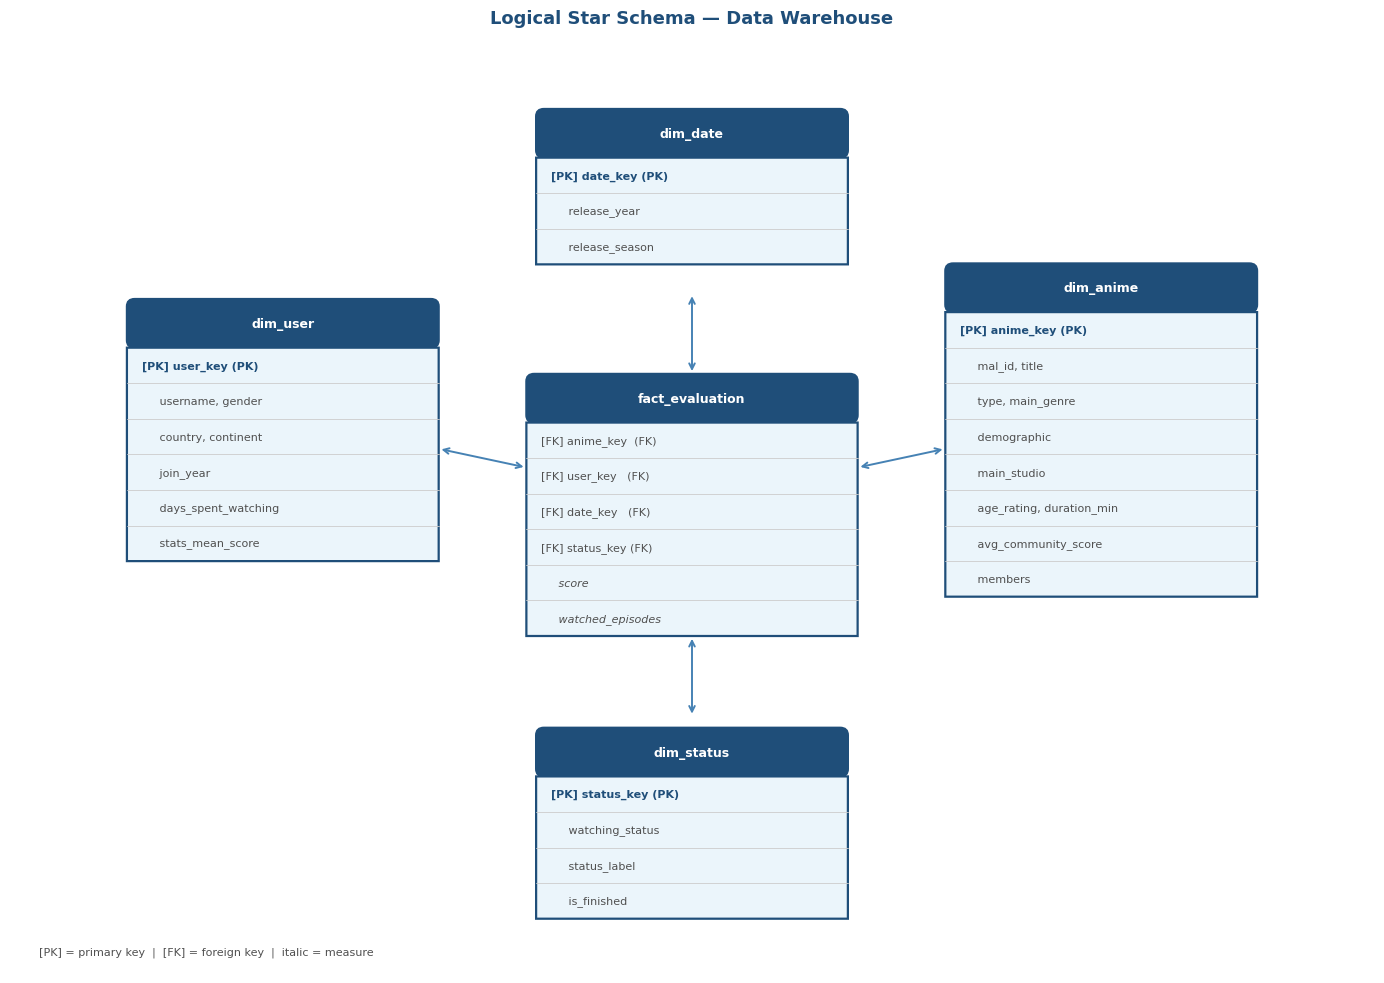

✓ star_schema.png saved to /content/drive/MyDrive/DW_Project/


In [62]:
# ── Star Schema diagram ───────────────────────────────────────────────────────
# Generates star_schema.png and saves it to BASE_PATH.

C_BLUE_DARK  = "#1F4E79"
C_BLUE_MED   = "#4682B4"
C_GRAY_DARK  = "#505050"

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('white')

def _tbox(cx, cy, title, rows, cw=3.2, rh=0.38, th=0.52):
    n = len(rows); total_h = th + n * rh
    x0 = cx - cw/2; y0 = cy - total_h/2
    ax.add_patch(FancyBboxPatch((x0, y0 + n*rh), cw, th,
        boxstyle="round,pad=0,rounding_size=0.08",
        fc=C_BLUE_DARK, ec=C_BLUE_DARK, lw=1.6, zorder=3))
    ax.text(cx, y0 + n*rh + th/2, title, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=4)
    ax.add_patch(FancyBboxPatch((x0, y0), cw, n*rh,
        boxstyle="round,pad=0,rounding_size=0.0",
        fc="#EBF5FB", ec=C_BLUE_DARK, lw=1.6, zorder=3))
    for i, (txt, style) in enumerate(rows):
        ry = y0 + (n - 1 - i) * rh + rh/2
        pre = "[PK] " if style == 'pk' else \
              ("[FK] " if style == 'fk' else "     ")
        ax.text(x0 + 0.15, ry, pre + txt, va='center', fontsize=8,
                fontweight='bold' if style == 'pk' else 'normal',
                fontstyle='italic' if style == 'measure' else 'normal',
                color=C_BLUE_DARK if style == 'pk' else C_GRAY_DARK,
                zorder=4)
        if i < n - 1:
            ax.plot([x0, x0 + cw],
                    [y0 + (n - 1 - i) * rh] * 2,
                    color='#cccccc', lw=0.6, zorder=3)
    return y0, y0 + total_h

def _bidir(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='<->',
                                color=C_BLUE_MED, lw=1.4,
                                mutation_scale=10), zorder=2)

# fact_evaluation (center)
fb, ft = _tbox(7.0, 5.0, "fact_evaluation",
    [("anime_key  (FK)", 'fk'), ("user_key   (FK)", 'fk'),
     ("date_key   (FK)", 'fk'), ("status_key (FK)", 'fk'),
     ("score",           'measure'),
     ("watched_episodes",'measure')], cw=3.4)

# dim_anime (right)
_tbox(11.2, 5.8, "dim_anime",
    [("anime_key (PK)",          'pk'),
     ("mal_id, title",           'normal'),
     ("type, main_genre",        'normal'),
     ("demographic",             'normal'),
     ("main_studio",             'normal'),
     ("age_rating, duration_min",'normal'),
     ("avg_community_score",     'normal'),
     ("members",                 'normal')])
_bidir(7 + 1.7, 5.4, 11.2 - 1.6, 5.6)

# dim_user (left)
_tbox(2.8, 5.8, "dim_user",
    [("user_key (PK)",       'pk'),
     ("username, gender",    'normal'),
     ("country, continent",  'normal'),
     ("join_year",           'normal'),
     ("days_spent_watching", 'normal'),
     ("stats_mean_score",    'normal')])
_bidir(2.8 + 1.6, 5.6, 7 - 1.7, 5.4)

# dim_date (top)
_, dt = _tbox(7.0, 8.4, "dim_date",
    [("date_key (PK)",  'pk'),
     ("release_year",   'normal'),
     ("release_season", 'normal')])
_bidir(7.0, 8.4 - 1.14, 7.0, ft)

# dim_status (bottom)
db, _ = _tbox(7.0, 1.6, "dim_status",
    [("status_key (PK)", 'pk'),
     ("watching_status", 'normal'),
     ("status_label",    'normal'),
     ("is_finished",     'normal')])
_bidir(7.0, 1.6 + 1.14, 7.0, fb)

ax.text(0.3, 0.2,
        "[PK] = primary key  |  [FK] = foreign key  |  italic = measure",
        fontsize=8, color=C_GRAY_DARK)
ax.set_title("Logical Star Schema — Data Warehouse",
             fontsize=13, fontweight='bold', color=C_BLUE_DARK, pad=10)

plt.tight_layout()
plt.savefig(BASE_PATH + 'star_schema.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ star_schema.png saved to", BASE_PATH)

## 6.5 — Sample OLAP queries

In [63]:
# Read valid keys from DW dimensions
with engine_dw.connect() as conn:
    valid_anime = set(pd.read_sql('SELECT anime_key FROM dim_anime', conn)['anime_key'].tolist())
    valid_users = set(pd.read_sql('SELECT user_key  FROM dim_user',  conn)['user_key'].tolist())

print(f"Valid anime keys: {len(valid_anime):,}")
print(f"Valid user keys : {len(valid_users):,}")

FACT_SQL = """
SELECT
    e.user_id  AS user_key,
    e.mal_id   AS anime_key,
    CASE CAST(e.watching_status AS INTEGER)
        WHEN 1 THEN 1
        WHEN 2 THEN 2
        WHEN 3 THEN 3
        WHEN 4 THEN 4
        ELSE 0
    END        AS status_key,
    e.score,
    e.watched_episodes
FROM evaluation e
"""

CHUNK = 500_000
total = 0
mode  = 'replace'

for i, chunk in enumerate(pd.read_sql(FACT_SQL, engine_rec, chunksize=CHUNK)):
    chunk = chunk[
        chunk['anime_key'].isin(valid_anime) &
        chunk['user_key'].isin(valid_users)
    ]
    chunk.to_sql('fact_evaluation', engine_dw, if_exists=mode, index=False)
    mode   = 'append'
    total += len(chunk)
    if (i + 1) % 5 == 0:
        print(f"  chunk {i+1:>3} — {total:>10,} rows loaded")

print(f"\nfact_evaluation loaded: {total:,} rows")

Valid anime keys: 28,627
Valid user keys : 302,673
  chunk   5 —  2,497,023 rows loaded
  chunk  10 —  4,994,290 rows loaded
  chunk  15 —  7,491,517 rows loaded
  chunk  20 —  9,988,811 rows loaded
  chunk  25 — 12,486,090 rows loaded
  chunk  30 — 14,983,404 rows loaded
  chunk  35 — 17,480,594 rows loaded
  chunk  40 — 19,977,954 rows loaded
  chunk  45 — 22,475,132 rows loaded
  chunk  50 — 24,972,455 rows loaded
  chunk  55 — 27,469,625 rows loaded
  chunk  60 — 29,967,043 rows loaded
  chunk  65 — 32,464,210 rows loaded
  chunk  70 — 34,961,574 rows loaded
  chunk  75 — 37,459,285 rows loaded
  chunk  80 — 39,956,620 rows loaded
  chunk  85 — 42,454,069 rows loaded
  chunk  90 — 44,951,811 rows loaded
  chunk  95 — 47,449,615 rows loaded
  chunk 100 — 49,947,219 rows loaded
  chunk 105 — 52,445,111 rows loaded
  chunk 110 — 54,942,847 rows loaded
  chunk 115 — 57,440,701 rows loaded
  chunk 120 — 59,938,424 rows loaded

fact_evaluation loaded: 60,859,167 rows


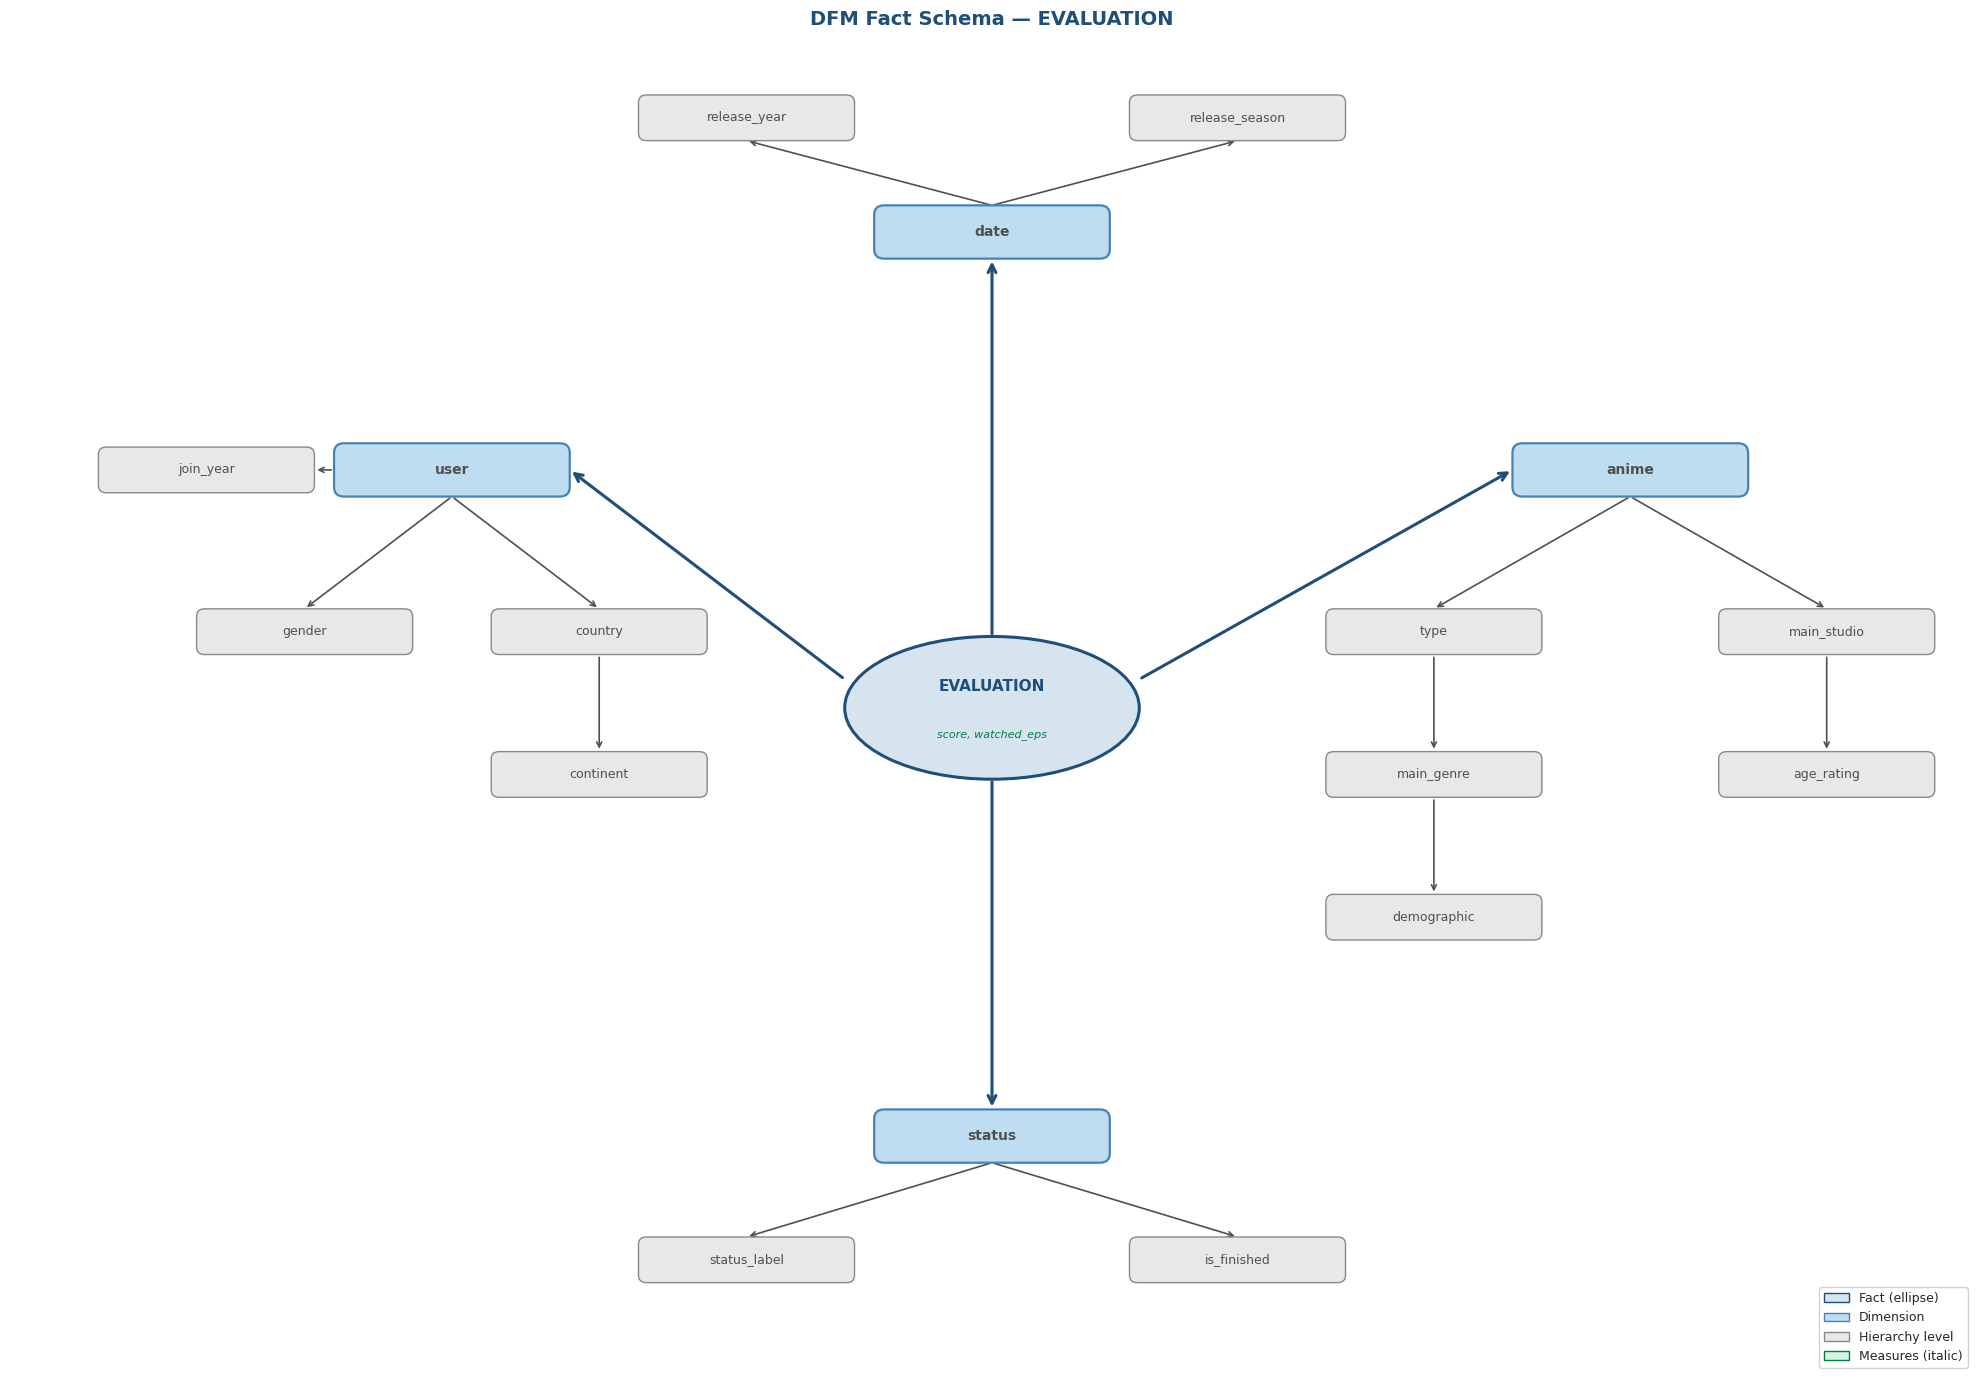

✓ dfm_schema.png saved to /content/drive/MyDrive/DW_Project/


In [64]:
# ── DFM Fact Schema diagram ───────────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

C_BLUE_DARK   = "#1F4E79"
C_BLUE_MED    = "#4682B4"
C_BLUE_LIGHT  = "#D6E4F0"
C_GREEN_DARK  = "#008040"
C_GREEN_LIGHT = "#D5F5E3"
C_GRAY        = "#E8E8E8"
C_GRAY_DARK   = "#505050"

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20); ax.set_ylim(0, 14); ax.axis('off')
fig.patch.set_facecolor('white')

# ── Fact ellipse (center) ─────────────────────────────────────────────────────
EX, EY = 10, 7
ax.add_patch(mpatches.Ellipse((EX, EY), 3.0, 1.5,
             fc=C_BLUE_LIGHT, ec=C_BLUE_DARK, lw=2.2, zorder=3))
ax.text(EX, EY+0.22, "EVALUATION", ha='center', va='center',
        fontsize=11, fontweight='bold', color=C_BLUE_DARK, zorder=4)
ax.text(EX, EY-0.28, "score, watched_eps", ha='center', va='center',
        fontsize=8, color=C_GREEN_DARK, style='italic', zorder=4)

def _dim(cx, cy, lbl):
    ax.add_patch(FancyBboxPatch((cx-1.2, cy-0.28), 2.4, 0.56,
        boxstyle="round,pad=0,rounding_size=0.1",
        fc="#BEDDF0", ec=C_BLUE_MED, lw=1.6, zorder=3))
    ax.text(cx, cy, lbl, ha='center', va='center',
            fontsize=10, fontweight='bold', color=C_GRAY_DARK, zorder=4)

def _hier(cx, cy, lbl):
    ax.add_patch(FancyBboxPatch((cx-1.1, cy-0.24), 2.2, 0.48,
        boxstyle="round,pad=0,rounding_size=0.08",
        fc=C_GRAY, ec="#888888", lw=1.0, zorder=3))
    ax.text(cx, cy, lbl, ha='center', va='center',
            fontsize=9, color=C_GRAY_DARK, zorder=4)

def _fe(x1, y1, x2, y2):
    """Fact → Dimension (thick blue)"""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->',
                                color=C_BLUE_DARK, lw=2.2,
                                mutation_scale=14), zorder=2)

def _he(x1, y1, x2, y2):
    """Hierarchy arrow (thin gray)"""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->',
                                color=C_GRAY_DARK, lw=1.2,
                                mutation_scale=9), zorder=2)

# ── DIM_USER (left) ───────────────────────────────────────────────────────────
UX, UY = 4.5, 9.5
_dim(UX, UY, "user")
_fe(EX-1.5, EY+0.3, UX+1.2, UY)        # ellipse → user (right edge of user)

_hier(2.0, 9.5, "join_year")
_he(UX-1.2, UY, 2.0+1.1, UY)           # user left → join_year right

_hier(3.0, 7.8, "gender")
_he(UX, UY-0.28, 3.0, 7.8+0.24)        # user bottom → gender top

_hier(6.0, 7.8, "country")
_he(UX, UY-0.28, 6.0, 7.8+0.24)        # user bottom → country top

_hier(6.0, 6.3, "continent")
_he(6.0, 7.8-0.24, 6.0, 6.3+0.24)     # country bottom → continent top

# ── DIM_ANIME (right) ─────────────────────────────────────────────────────────
ANX, ANY = 16.5, 9.5
_dim(ANX, ANY, "anime")
_fe(EX+1.5, EY+0.3, ANX-1.2, ANY)      # ellipse → anime (left edge of anime)

_hier(14.5, 7.8, "type")
_he(ANX, ANY-0.28, 14.5, 7.8+0.24)     # anime bottom → type top

_hier(14.5, 6.3, "main_genre")
_he(14.5, 7.8-0.24, 14.5, 6.3+0.24)   # type → main_genre

_hier(14.5, 4.8, "demographic")
_he(14.5, 6.3-0.24, 14.5, 4.8+0.24)   # main_genre → demographic

_hier(18.5, 7.8, "main_studio")
_he(ANX, ANY-0.28, 18.5, 7.8+0.24)     # anime bottom → main_studio top

_hier(18.5, 6.3, "age_rating")
_he(18.5, 7.8-0.24, 18.5, 6.3+0.24)   # main_studio → age_rating

# ── DIM_DATE (top) ────────────────────────────────────────────────────────────
_dim(10.0, 12.0, "date")
_fe(EX, EY+0.75, 10.0, 12.0-0.28)      # ellipse top → date bottom

_hier(7.5, 13.2, "release_year")
_he(10.0, 12.0+0.28, 7.5, 13.2-0.24)  # date top → release_year

_hier(12.5, 13.2, "release_season")
_he(10.0, 12.0+0.28, 12.5, 13.2-0.24) # date top → release_season

# ── DIM_STATUS (bottom) ───────────────────────────────────────────────────────
_dim(10.0, 2.5, "status")
_fe(EX, EY-0.75, 10.0, 2.5+0.28)       # ellipse bottom → status top

_hier(7.5, 1.2, "status_label")
_he(10.0, 2.5-0.28, 7.5, 1.2+0.24)    # status bottom → status_label

_hier(12.5, 1.2, "is_finished")
_he(10.0, 2.5-0.28, 12.5, 1.2+0.24)   # status bottom → is_finished

ax.legend(handles=[
    mpatches.Patch(fc=C_BLUE_LIGHT, ec=C_BLUE_DARK,  label='Fact (ellipse)'),
    mpatches.Patch(fc="#BEDDF0",    ec=C_BLUE_MED,   label='Dimension'),
    mpatches.Patch(fc=C_GRAY,       ec="#888888",     label='Hierarchy level'),
    mpatches.Patch(fc=C_GREEN_LIGHT,ec=C_GREEN_DARK,  label='Measures (italic)'),
], loc='lower right', fontsize=9, framealpha=0.9)

ax.set_title("DFM Fact Schema — EVALUATION",
             fontsize=14, fontweight='bold', color=C_BLUE_DARK, pad=12)

plt.tight_layout()
plt.savefig(BASE_PATH + 'dfm_schema.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ dfm_schema.png saved to", BASE_PATH)

## 7.0 — Tableau Public Export

In [ ]:
# ── Tableau Public Export (pre-aggregated views) ─────────────────────────
# Tableau Public limits: 15M rows / 1GB per workbook.
# Solution: export one pre-aggregated CSV per analysis instead of raw fact rows.
# All 60M evaluations are used — aggregation happens here in Python, not Tableau.

EXPORT_DIR = '/content/drive/MyDrive/DW_Project/tableau_export'
os.makedirs(EXPORT_DIR, exist_ok=True)

def export(name, sql):
    df = pd.read_sql(sql, engine_dw)
    path = os.path.join(EXPORT_DIR, f'{name}.csv')
    df.to_csv(path, index=False)
    kb = os.path.getsize(path) / 1024
    print(f"  ✅ {name:<40} {len(df):>7,} rows  {kb:>7,.0f} KB")
    return df

print("Exporting aggregated views for Tableau Public...\n")

# V1 — Average score by genre and release year
# OLAP: drill-down on year, slice by genre
export("v1_score_by_genre_year", """
    SELECT
        a.main_genre                        AS genre,
        a.release_year,
        ROUND(AVG(f.score), 2)              AS avg_score,
        COUNT(*)                            AS n_evaluations,
        COUNT(DISTINCT f.anime_key)         AS n_anime
    FROM fact_evaluation f
    JOIN dim_anime a ON f.anime_key = a.anime_key
    WHERE f.score IS NOT NULL
      AND a.main_genre IS NOT NULL
      AND a.release_year IS NOT NULL
    GROUP BY a.main_genre, a.release_year
    ORDER BY a.release_year, a.main_genre
""")

# V2 — Top anime by number of evaluations
# OLAP: slice by type/genre, rank by popularity or score
export("v2_top_anime", """
    SELECT
        a.anime_key,
        a.title,
        a.type,
        a.main_genre,
        a.demographic,
        a.release_year,
        a.release_season,
        a.age_rating,
        a.avg_community_score,
        a.members,
        COUNT(*)                            AS n_evaluations,
        ROUND(AVG(f.score), 2)             AS avg_user_score,
        ROUND(AVG(f.watched_episodes), 1)  AS avg_episodes_watched
    FROM fact_evaluation f
    JOIN dim_anime a ON f.anime_key = a.anime_key
    WHERE f.score IS NOT NULL
    GROUP BY a.anime_key
    ORDER BY n_evaluations DESC
    LIMIT 2000
""")

# V3 — Evaluations and score by user country
# OLAP: roll-up country → continent, slice by gender
export("v3_users_by_country", """
    SELECT
        u.country,
        u.continent,
        u.gender,
        COUNT(*)                            AS n_evaluations,
        COUNT(DISTINCT f.user_key)          AS n_users,
        ROUND(AVG(f.score), 2)             AS avg_score,
        ROUND(AVG(u.days_spent_watching), 1) AS avg_days_watching
    FROM fact_evaluation f
    JOIN dim_user u ON f.user_key = u.user_key
    WHERE u.country IS NOT NULL
    GROUP BY u.country, u.continent, u.gender
    ORDER BY n_evaluations DESC
""")

# V4 — Score distribution by watching status and anime type
# OLAP: dice (status × type), slice by score
export("v4_score_by_status_type", """
    SELECT
        s.status_label                      AS watching_status,
        s.is_finished,
        a.type                              AS anime_type,
        f.score,
        COUNT(*)                            AS n_evaluations
    FROM fact_evaluation f
    JOIN dim_status s ON f.status_key = s.status_key
    JOIN dim_anime  a ON f.anime_key  = a.anime_key
    WHERE f.score IS NOT NULL
      AND a.type IS NOT NULL
    GROUP BY s.status_label, s.is_finished, a.type, f.score
    ORDER BY s.status_label, a.type, f.score
""")

# V5 — Studio quality ranking
# OLAP: roll-up anime → studio, slice by type
export("v5_studio_ranking", """
    SELECT
        a.main_studio,
        a.type,
        COUNT(DISTINCT a.anime_key)         AS n_anime,
        COUNT(*)                            AS n_evaluations,
        ROUND(AVG(f.score), 2)             AS avg_score,
        ROUND(AVG(a.avg_community_score), 2) AS avg_community_score
    FROM fact_evaluation f
    JOIN dim_anime a ON f.anime_key = a.anime_key
    WHERE f.score IS NOT NULL
      AND a.main_studio IS NOT NULL
    GROUP BY a.main_studio, a.type
    HAVING n_evaluations >= 500
    ORDER BY avg_score DESC
""")

# V6 — User engagement cohort by join year
# OLAP: drill-down join_year, roll-up continent
export("v6_user_cohort", """
    SELECT
        u.join_year,
        u.continent,
        u.gender,
        COUNT(DISTINCT f.user_key)          AS n_users,
        COUNT(*)                            AS n_evaluations,
        ROUND(AVG(f.score), 2)             AS avg_score,
        ROUND(AVG(u.days_spent_watching), 1) AS avg_days_watching,
        ROUND(AVG(u.stats_mean_score), 2)  AS avg_personal_mean_score
    FROM fact_evaluation f
    JOIN dim_user u ON f.user_key = u.user_key
    WHERE u.join_year IS NOT NULL
    GROUP BY u.join_year, u.continent, u.gender
    ORDER BY u.join_year
""")

print(f"\n✅ All exports saved to: {EXPORT_DIR}")

Exporting aggregated views for Tableau Public...



## 7.1 — Tableau Public setup guide

### Files exported (in your Google Drive → DW_Project/tableau_export/)
| File | Approx. rows | Used for |
|------|-------------|----------|
| `v1_score_by_genre_year.csv` | ~3,000 | Score trend over time by genre |
| `v2_top_anime.csv` | 2,000 | Most popular and highest-rated anime |
| `v3_users_by_country.csv` | ~5,000 | Geographic map of anime consumption |
| `v4_score_by_status_type.csv` | ~500 | Score vs watching status |
| `v5_studio_ranking.csv` | ~1,000 | Studio quality ranking |
| `v6_user_cohort.csv` | ~800 | User cohort analysis by join year |

### How to import into Tableau Public Desktop
1. Open Tableau Public Desktop
2. Connect → **Text File** → select **one** CSV at a time
3. Each CSV is self-contained — no manual joins needed
4. Create a new sheet for each CSV

### OLAP operations covered
| Analysis | Operation | How in Tableau |
|----------|-----------|----------------|
| Year → Season | Drill-down | Hierarchy on release_year / release_season |
| Country → Continent | Roll-up | Hierarchy on country / continent |
| Genre × Status | Dice | Filter on both dimensions simultaneously |
| Completed TV only | Slice | Filter anime_type = TV, is_finished = 1 |